In [5]:
#!pip install "PolyBin3D @ git+https://github.com/oliverphilcox/PolyBin3D"
#!pip install git+https://github.com/cosmodesi/pypower
#!mkdir precomps
#!pip install colossus

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cmass 0.0.0 requires optuna, which is not installed.
cmass 0.0.0 requires torch, which is not installed.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from funcs import get_delta, compute_Pk, compute_Bk,calculate_acc_from_phi_k, correct_pos, compute_XPk, get_roots,MAS_correction, terms_root, get_roots_gamma, terms_root_gamma, get_roots_overdensity
import scipy
import h5py, itertools
from scipy.fft import *

import progressbar
import inspect
import os
from sys import getsizeof

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.colors as colors
import colorsys
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Circle, Rectangle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
import matplotlib.ticker as mtick

# Pylians
import readgadget
import MAS_library as MASL
import Pk_library as PKL
import plotting_library as PL
import smoothing_library as SL
from Pk_library import MAS_correction as MAS_corr_pylians
import density_field_library as DFL
#from nbodykit.lab import *

# pypower
from pypower import CatalogMesh, MeshFFTPower, CatalogFFTPower, PowerSpectrumStatistics, utils, setup_logging

# Scipy
from scipy.interpolate import interp1d

#Polybin3D
import PolyBin3D as pb

# Emulators
import symbolic_pofk.syrenhalofit as syrenhalofit
import symbolic_pofk.linear as linear
import astropy.cosmology as cosmo

# Conveniences
format_float = lambda z: "%ip%i"%(int(z // 1), int(z%1 *10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return a + r"$\times 10^{%i}$"%b

plt.style.use("dark_background")
#plt.style.use("default")

import time
print("Numpy Version: ", np.__version__)
# For opti tests
import pyfftw
from numba import njit, jit, prange

import psutil, gc
from psutil._common import bytes2human
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())
#print("Treads for OpenMP :", os.environ["OMP_NUM_THREADS"] )

figroot = os.path.join("Figures", "Pypower")

--------------------------------------------------------------------------

  Local host:   a200
  Local device: mlx5_0
--------------------------------------------------------------------------
[a200.anvil.rcac.purdue.edu:2576253] common_ucx.c:362  Warning: UCX is unable to handle VM_UNMAP event. This may cause performance degradation or data corruption. Pls try adding --mca opal_common_ucx_opal_mem_hooks 1 to mpirun/oshrun command line to resolve this issue.


Numpy Version:  1.23.5
total memory: 251.5G
memory % used: 47.3
number of cpus : 128


In [2]:
def get_size(obj):
    if isinstance(obj, np.ndarray):
        return obj.nbytes          # actual buffer size, not just object overhead
    return sys.getsizeof(obj)

sizes = []
for name, val in list(globals().items()):
    if name.startswith('_'):
        continue
    try:
        sizes.append((name, get_size(val)))
    except Exception:
        pass

sizes.sort(key=lambda x: -x[1])

def human(n):
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if abs(n) < 1024:
            return f"{n:7.1f} {unit}"
        n /= 1024
    return f"{n:7.1f} PB"

for name, size in sizes[:25]:
    print(f"{name:30s} {human(size)}")

print("---")
print("Total tracked:", human(sum(s for _, s in sizes)))

---
Total tracked:     0.0 B


In [3]:
!cat /sys/fs/cgroup/memory.current 2>/dev/null || cat /sys/fs/cgroup/memory/memory.usage_in_bytes
!cat /sys/fs/cgroup/memory.max 2>/dev/null || cat /sys/fs/cgroup/memory/memory.limit_in_bytes

15921188864
9223372036854771712


# 0) Very brief summary
**A handful of equation for different test cases**

The goal is to perturbed particles positions 

\begin{align}
\mathbf{x}_i' = \mathbf{x}_i + \nabla\phi(\mathbf{x}_i)
\end{align}

To properly check the dimensions of the terms in equations, we need to remind our Fourier convention in periodic (cubic) boxes

\begin{align}
    \Delta_\mathbf{k} &= \frac{1}{V} \int_V \Delta(\mathbf{x}) e^{-i\mathbf{k} \cdot \mathbf{x}} \, d^3\mathbf{x} \\
    \Delta_\mathbf{x} &=  \sum_\mathbf{k} \Delta_\mathbf{k} e^{i\mathbf{k} \cdot \mathbf{x}} 
\end{align}

## Main equations

We use the convention that $\Delta$ designates the fractional overdensity field, meaning in comoving space

$\Delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \rho_\text{mean}}{\rho_\text{mean}}$
with $\rho(\mathbf{x}) = \sum_{i=1}^n \delta(\mathbf{x} - \mathbf{x}_i)$ defined with the Delta function.

The main equation for the Fourier transform of the density field of the perturbed tracer $\Delta_k^{'}$ is

\begin{align}\label{eq:Delta_prime_k_new}
|\Delta^{'}_\mathbf{k}|^2 &= \Delta^{'}_\mathbf{k}\Delta^{' \ast}_\mathbf{k}  \\
&= \left[ \Delta_\mathbf{k} + k^2\phi_{\mathbf{k}} +
\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}} 
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}
    +\frac{1}{2}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}  
\right) \right] \times \nonumber\\
&\left[\Delta^{\ast}_\mathbf{k} + k^2\phi_{\mathbf{k}}^{\ast} +
\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber\\
|\Delta^{'}_\mathbf{k}|^2 &\approx_{\mathcal{O}(\phi^2)} |\Delta_{\mathbf{k}}|^2 + k^4 |\phi_{\mathbf{k}}|^2 + \sum_{\mathbf{q},\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \phi_{\mathbf{q}}
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast} \nonumber\\
 &+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\phi_{\mathbf{k}}^{\ast} +k^2 \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{k}}\phi_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} \right. \nonumber \\
 &+\left. \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber 
\end{align}




**MAS kernel reminder**

In the review by [Angulo & Hahn](https://arxiv.org/abs/2112.05165), equation 62 reminds the formulae for the MAS kernel Fourier transform (p=1 for NGP and 2 for CiC)

\begin{equation}
W(k) = \left[ \mathrm{sin}_c(\frac{\pi k}{2 k_N}) \right]^p
\end{equation}

where the Nyquist wavenumber is $k_N = \frac{\pi N}{L} = \frac{1}{2}\frac{2\pi}{\Delta_x}$.

**17th of December 2025**
- without the quad. term in gamma, with the bispectrum, we can turn the system as a linear matrix form inversion (integral as sum)
- for the uncorrelated case below, same idea for the linear inversion with sums instead of numerical integrals.
- if in the end root finding is required, turn to Jax with custom gradients (homework: to derive)
- weekly reminder: interlacing estimators exist :) 

**21rst of January 2026**
- clean the correlated case with pypower, make term contributions plot
- do the bispectrum system with the pypower Pks, with and without the gamma quadratic term
- uncorrelated case: restart with pypower
- make the plot gamma_k instead of gamma_k over k^2 (just after finding the roots)

**18th of Feb.**
- also check the unit of the bispectrum term, and the adequacy of the volume factor when it comes to terms comparison ( Correlated case)

**9th of April 2026**
- with pypower, do we have access to the interlacing fields? :for the uncorrelated case
- to understand this: read and understand [this paper](https://iopscience.iop.org/article/10.1086/427087) and [this one](https://arxiv.org/abs/1512.07295)

## Functions and numba implementation for displacements

In [4]:
def MAS_correction(x, MAS_index):
    '''
    x is a 3d array in practice
    '''
    x = np.asarray(x)  # Ensure x is an array
    out = np.ones_like(x)
    nonzero = x != 0.0
    out[nonzero] = (x[nonzero] / np.sin(x[nonzero])) ** MAS_index
    return out

def compute_Pk(delta, BoxSize=1000.0, MAS='CIC', axis=0, verbose=True):    

    # compute power spectrum
    Pk = PKL.Pk(delta, BoxSize, axis=axis, MAS=MAS, threads=1, verbose=verbose)
    
    # 3D P(k)
    k       = Pk.k3D
    Pk0     = Pk.Pk[:,0] #monopole
    Pk2     = Pk.Pk[:,1] #quadrupole
    Pk4     = Pk.Pk[:,2] #hexadecapole

    return k, Pk0, Pk2, Pk4


def compute_XPk(delta1, delta2, BoxSize=1000.0, MAS=['CIC', 'CIC'], axis=0):    

    # compute cross-power spectrum    
    Pk = PKL.XPk([delta1,delta2], BoxSize, axis=axis, MAS=MAS, threads=1)
    
    # 3D P(k)
    k       = Pk.k3D
    Pk0_X  = Pk.XPk[:,0,0] #monopole of 1-2 cross P(k)
    Pk2_X  = Pk.XPk[:,1,0] #quadrupole of 1-2 cross P(k)
    Pk4_X  = Pk.XPk[:,2,0] #hexadecapole of 1-2 cross P(k)

    return k, Pk0_X, Pk2_X, Pk4_X

def get_delta(pos, grid, W=0, mass=1, BoxSize=1000.0, MAS='CIC', verbose=True):
    
    """
    W: weights corresponding to each particle position. (i.e. W=0 for equal weighting to each particle, W=1, mass=mass for mass weighting)
    
    """
    
    # define 3D density field
    delta = np.zeros((grid,grid,grid), dtype=np.float32)
    
    # construct 3D density field
    if W:
        MASL.MA(pos, delta, BoxSize, MAS, W=mass, verbose=verbose)
    else:
        MASL.MA(pos, delta, BoxSize, MAS, verbose=verbose)
          
    
    # at this point, delta contains the effective number of particles in each voxel
    # now compute overdensity and density constrast
    delta /= np.mean(delta, dtype=np.float64)
    delta -= 1.0
    
    return delta

In [5]:
def terms_root(k, Pk0, Pk0_target):
    I2=np.diag(k**4)
    # A=(I+I2)
    A=I2
    a=np.matmul(A,Pk0)


    I3=np.diag(2*k**2)
    b=np.matmul(I3,Pk0)

    c=Pk0 - Pk0_target
    return a,b,c

def terms_root_gamma(k, Pk0, Pk0_target):
    a = Pk0
    b = 2*Pk0
    c=Pk0 - Pk0_target
    return a,b,c

def get_roots_gamma(k, Pk0, Pk0_target, BoxSize=1000.):
    a = Pk0
    b = 2*Pk0
    c=Pk0-Pk0_target
    coeffs=np.column_stack([a,b,c])
    roots=np.array([np.roots(coeffs[i]) for i in range(len(k))])

    return roots, coeffs

def get_roots(k, Pk0, Pk0_target, BoxSize=1000.):

    I2=np.diag(k**4)
    # A=(I+I2)
    A=I2
    a=np.matmul(A,Pk0)


    I3=np.diag(2*k**2)
    b=np.matmul(I3,Pk0)

    c=Pk0-Pk0_target

    coeffs=np.column_stack([a,b,c])
    roots=np.array([np.roots(coeffs[i]) for i in range(len(k))])

    return roots, coeffs

In [6]:
np.interp?

Signature: np.interp(x, xp, fp, left=None, right=None, period=None)
Docstring:
One-dimensional linear interpolation for monotonically increasing sample points.

Returns the one-dimensional piecewise linear interpolant to a function
with given discrete data points (`xp`, `fp`), evaluated at `x`.

Parameters
----------
x : array_like
    The x-coordinates at which to evaluate the interpolated values.

xp : 1-D sequence of floats
    The x-coordinates of the data points, must be increasing if argument
    `period` is not specified. Otherwise, `xp` is internally sorted after
    normalizing the periodic boundaries with ``xp = xp % period``.

fp : 1-D sequence of float or complex
    The y-coordinates of the data points, same length as `xp`.

left : optional float or complex corresponding to fp
    Value to return for `x < xp[0]`, default is `fp[0]`.

right : optional float or complex corresponding to fp
    Value to return for `x > xp[-1]`, default is `fp[-1]`.

period : None or float, opt

In [7]:
#####################################################################
# NN = Nearest Neighbor interpolations, older functions for reference
#####################################################################
@njit
def gradient_nn(positions, grad_nnx, grad_nny, grad_nnz, grad_x, grad_y, grad_z, array_length, max_length):
    '''
    Nearest neighbor computation
    '''
    N = positions.shape[0]
    for n in prange(N):

        # Calculate at nearest voxel
        x_index = np.argmin((positions[n,0] - array_length)**2)
        y_index = np.argmin((positions[n,1] - array_length)**2)
        z_index = np.argmin((positions[n,2] - array_length)**2)

        grad_nnx[n] = grad_x[x_index,y_index,z_index]
        grad_nny[n] = grad_y[x_index,y_index,z_index]
        grad_nnz[n] = grad_z[x_index,y_index,z_index]
        
    return grad_nnx, grad_nny, grad_nnz

@njit
def displace_positions_nn(positions, new_positions, grad_x, grad_y, grad_z, array_length, max_length):
    '''
    Nearest neighbor computation
    '''
    N = positions.shape[0]
    for n in prange(N):

        # Calculate at nearest voxel
        x_index = np.argmin((positions[n,0] - array_length)**2)
        y_index = np.argmin((positions[n,1] - array_length)**2)
        z_index = np.argmin((positions[n,2] - array_length)**2)

        new_positions[n,0] = np.mod(positions[n,0] + grad_x[x_index,y_index,z_index], max_length)
        new_positions[n,1] = np.mod(positions[n,1] + grad_y[x_index,y_index,z_index], max_length)
        new_positions[n,2] = np.mod(positions[n,2] + grad_z[x_index,y_index,z_index], max_length)
        
    return new_positions

##############################################################
# Trilinear interpolation with periodic bounds, default scheme
##############################################################
@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    """
    Trilinear interpolation on a REGULAR 3D array using Numba.
    For irregular 3D grids, we could do some slight modifications

    Args:
        data (np.ndarray): The 3D array containing the data to interpolate.
        points (np.ndarray): A 2D array where each row represents query coordinates (x, y, z).
        x_coords (np.ndarray): 1D array of x-coordinates for the data grid.
        y_coords (np.ndarray): 1D array of y-coordinates for the data grid.
        z_coords (np.ndarray): 1D array of z-coordinates for the data grid.

    Returns:
        np.ndarray: An array of interpolated values corresponding to the query points.
    """
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)

    # ASSUMING REGULAR GRIDS: Pre-calculate inverse outside the loop
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0]) 

    print(dx_inv, dy_inv, dz_inv)

    for i in prange(num_points):
        
        x_query, y_query, z_query = points[i,:]

        # Indices of cube around query point
        x0_idx = np.searchsorted(x_coords, x_query, side = "left")-1
        y0_idx = np.searchsorted(y_coords, y_query, side = "left")-1
        z0_idx = np.searchsorted(z_coords, z_query, side = "left")-1

        # Ensure bounds are correct
        #x0_idx = max(0, min(x0_idx, nx - 2))
        #y0_idx = max(0, min(y0_idx, ny - 2))
        #z0_idx = max(0, min(z0_idx, nz - 2))
        x0_idx = x0_idx%nx
        y0_idx = y0_idx%ny
        z0_idx = z0_idx%nz
        x1_idx = (x0_idx + 1)%nx # not needed because regular grid ! -> Actually we need for periodic conditions
        y1_idx = (y0_idx + 1)%ny
        z1_idx = (z0_idx + 1)%ny

        x0 = x_coords[x0_idx]
        y0 = y_coords[y0_idx]
        z0 = z_coords[z0_idx]

        # Linear interpolation weights
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv

        # Perform trilinear interpolation (hard-coded formula for 8 corners)
        c000 = data[x0_idx, y0_idx, z0_idx]
        c100 = data[x1_idx, y0_idx, z0_idx]
        c010 = data[x0_idx, y1_idx, z0_idx]
        c001 = data[x0_idx, y0_idx, z1_idx]
        c110 = data[x1_idx, y1_idx , z0_idx]
        c101 = data[x1_idx, y0_idx, z1_idx]
        c011 = data[x0_idx, y1_idx, z1_idx]
        c111 = data[x1_idx, y1_idx, z1_idx]

        interpolated_value = (
            c000 * (1 - xd) * (1 - yd) * (1 - zd) +
            c100 * xd * (1 - yd) * (1 - zd) +
            c010 * (1 - xd) * yd * (1 - zd) +
            c001 * (1 - xd) * (1 - yd) * zd +
            c110 * xd * yd * (1 - zd) +
            c101 * xd * (1 - yd) * zd +
            c011 * (1 - xd) * yd * zd +
            c111 * xd * yd * zd
        )
        interpolated_values[i] = interpolated_value

    return interpolated_values

@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z, x_c, y_c, z_c, max_length, threshold = None):
    '''
    3D interpolation in numba computation
    '''
    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c) #"c" for comoving coordinates
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c)
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c)

    if threshold is not None:
        nabla_x[np.abs(nabla_x)>threshold]=0
        nabla_y[np.abs(nabla_y)>threshold]=0
        nabla_z[np.abs(nabla_z)>threshold]=0

    # Also make periodic boundary conditions
    new_positions[:,0] = np.mod(positions[:,0] + nabla_x , max_length)
    new_positions[:,1] = np.mod(positions[:,1] + nabla_y , max_length)
    new_positions[:,2] = np.mod(positions[:,2] + nabla_z , max_length)
            
    return new_positions, nabla_x, nabla_y, nabla_z

##############################################
# Fourier operations for the 3D (regular) grid
##############################################

# @jit(nopython=True) has for alias @njit
@njit
def fill_fourier_grid(weights_grid, k3D_radius , k_bins, weights1D, extra_right = None):
    '''
    interpolate the gamma_k/k**2=weights1D to multiplty the three-dimensional Phi_k with
    '''
    for ix in prange(k3D_radius.shape[0]):
        for iy in prange(k3D_radius.shape[1]):
            for iz in prange(k3D_radius.shape[2]):
                k_val = k3D_radius[ix, iy, iz]
                # Need for an if, because left/right arguments make nopython mode fail
                if k_val > k_bins[-1] and extra_right is not None:
                    weights_grid[ix, iy, iz] = extra_right
                else:
                    weights_grid[ix, iy, iz] = np.interp(k_val, k_bins, weights1D) #(x,xp,fp)
    return weights_grid

def fourier_shells_k(res, box_size, fshift = True):
    '''
    Use fhsift=True to move the zero frequency component at the center of arrays
    '''
    scale = 2*np.pi*res/box_size # k resolution
    if fshift:
        k_x = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_y = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_z = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32') # not fftshift for redundant "refreq" case
    else:
        k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_y = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_z = np.array(scale*np.fft.fftfreq(res), dtype='float32')

    kx, ky, kz = np.meshgrid(k_x, k_y, k_z, indexing='ij')
    k_radius_grid = np.sqrt(kx**2 + ky**2 + kz**2)
        
    return k_x, k_y, k_z, k_radius_grid

# 1) Setup and load data
The Quijote fiducial simulations parameters are reminded in the [documentation](https://quijote-simulations.readthedocs.io/en/latest/types.html). 
We will try to perturb a L-PICOLA snapshot, with the reference being either the Quijote simulation at the same seed or from the [symbolik_pofk](https://github.com/DeaglanBartlett/symbolic_pofk) emulator.

In [8]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8":0.834, "n_s":0.9624, "h":0.671, "Omega_b":0.049,
            "Omega_m":0.3175}

In [9]:
# SETUP PARAMS
grid = 256
BoxSize=1000.0 # Mpc/h
#voxel_size = np.array(3*[BoxSize/grid])
MAS='CIC'
MAS_index=2

kNyquist = np.pi * grid/BoxSize
kFund = 2*np.pi/BoxSize

redshift = 0.5
a = 1 / (1+redshift)
z_str = format_float(redshift)
seed = 1

# SNAPSHOT LOCATIONS
nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003"%(z_str,seed)
nbodystr = "Quijote"

app = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500"%(z_str,seed)
appstr = "LPICOLA"
ptype   = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

basedir = "/home/x-nchartier/PkCorr/Figures"

if not os.path.exists(os.path.join(basedir, appstr)):
    os.makedirs(os.path.join(basedir, appstr), exist_ok=False)

# TODO: test on fastpm sims with saved DM particles
# fpm = "/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/%i/"%seed
# file = h5py.File(os.path.join(fpm, "nbody.h5"))
# print(file.keys())
# data = file['0.666667']
# print(data.keys())
# file.close()

In [10]:
# read header for nbody
header   = readgadget.header(nbody)
BoxSize  = header.boxsize/1e3  #Mpc/h
print("BoxSize = %.1f Mpc"%BoxSize)
Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3)
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
print(r"$\Omega_m = %.4f$"%Omega_m)
Omega_l  = header.omega_l      #value of Omega_l
print(r"$\Omega_{\Lambda} = %.4f$"%Omega_l)
h        = header.hubble       #value of h
print(r"$h=%.4f$"%h)
#redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble)
Hubble_0   = 100.0*np.sqrt(Omega_m+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble_0)
print(h*Hubble_0)

# read positions, velocities and IDs of the particles
pos_nb = readgadget.read_block(nbody, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_nb = readgadget.read_block(nbody, "VEL ", ptype)     #peculiar velocities in km/s
#ids_nb = readgadget.read_block(nbody, "ID  ", ptype)-1   #IDs starting from 0

BoxSize = 1000.0 Mpc
[1.]
$\Omega_m = 0.3175$
$\Omega_{\Lambda} = 0.6825$
$h=0.6711$
132.44102461095656
100.0
67.11


In [11]:
# read header for nbody
header   = readgadget.header(app)

Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3) # sanity check

# read positions, velocities and IDs of the particles
pos_pm = readgadget.read_block(app, "POS ", ptype)/1e3 #positions in Mpc/h
print(pos_pm.shape)
#vel_pm = readgadget.read_block(app, "VEL ", ptype)     #peculiar velocities in km/s
#ids_pm = readgadget.read_block(app, "ID  ", ptype)-1   #IDs starting from 0

[1.]
(134217728, 3)


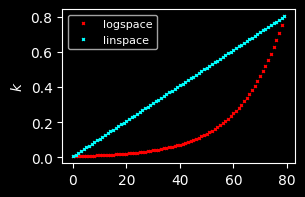

In [12]:
num_bins = 80
kedges1 = np.logspace(np.log10(2*np.pi/BoxSize), np.log10(kNyquist), num_bins)
kedges2 = np.linspace(2*np.pi/BoxSize, kNyquist, num_bins)
plt.figure(figsize = (3,2))
plt.plot(kedges1, ls='None', marker='x', color = "red", markersize = 2, label ='logspace')
plt.plot(kedges2, ls='None', marker='x', color = "cyan", markersize = 2, label = 'linspace')
plt.legend(fontsize = 8)
plt.ylabel(r'$k$') ;# plt.yscale('log')

In [13]:
## PYLIANS COMPUTATION ##
# PM
delta_pm_alt = get_delta(pos=pos_pm, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_pm_alt, Pk_pm_alt, _, _ = compute_Pk(delta_pm_alt, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# N-body (=target if no emulator)
delta_nb_alt = get_delta(pos=pos_nb, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_nb_alt, Pk_nb_alt, _, _ = compute_Pk(delta_nb_alt, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X_alt, Pk_X_alt, _, _ = compute_XPk(delta_pm_alt, delta_nb_alt, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rk_alt = Pk_X_alt/np.sqrt(Pk_pm_alt*Pk_nb_alt)


## PYPOWER COMPUTATION ##
# With loading and saving data given computation times
num_bins = 50
# num_bins = 80
interlacing_order = 2
#kedges = np.linspace(0, kNyquist, num_bins)
kedges = np.linspace(kFund, kNyquist, num_bins)[:-1] # getting rid now of future nan value above kNyquist and below kF
ells = (0)

if os.path.exists(os.path.join('precomps', "pypower_pm_%i_bins.npy"%num_bins)) and os.path.exists(os.path.join("precomps", "pypower_nb_%i_bins.npy"%num_bins)):
    print("LOADING PYPOWER COMPUTATIONS")
    k_pm = np.load(os.path.join('precomps', 'kpm_%i_bins.npy'%num_bins))
    k_nb = np.load(os.path.join('precomps', 'knb_%i_bins.npy'%num_bins))
    Pk_pm = np.load(os.path.join('precomps', "pypower_pm_%i_bins.npy"%num_bins))
    Pk_nb = np.load(os.path.join('precomps', "pypower_nb_%i_bins.npy"%num_bins))
    k_pm_raw = np.load(os.path.join('precomps', 'kpm_raw_%i_bins.npy'%num_bins))
    k_nb_raw = np.load(os.path.join('precomps', 'knb_raw_%i_bins.npy'%num_bins))
    Pk_pm_raw = np.load(os.path.join('precomps', "pypower_pm_raw_%i_bins.npy"%num_bins))
    Pk_nb_raw = np.load(os.path.join('precomps', "pypower_nb_raw_%i_bins.npy"%num_bins))
    k_X = np.load(os.path.join('precomps', 'kX_%i_bins.npy'%num_bins))
    Pk_X = np.load(os.path.join('precomps', "pypower_X_%i_bins.npy"%num_bins))
else:
    print("RUNNING PYPOWER COMPUTATIONS")
    start = time.time()
    result_pm = CatalogFFTPower(data_positions1=pos_pm, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    result_nb = CatalogFFTPower(data_positions1=pos_nb, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    result_X = CatalogFFTPower(data_positions1=pos_nb, data_positions2 = pos_pm, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    #result_pm.poles(remove_shotnoise=False)
    poles_pm = result_pm.poles
    poles_nb = result_nb.poles
    k_pm, Pk_pm = poles_pm(ell=ells, return_k=True, complex=False)
    k_nb, Pk_nb = poles_nb(ell=ells, return_k=True, complex=False)

    # For cross correlation coefficients
    k_pm_raw, Pk_pm_raw = poles_pm(ell=ells, return_k=True, complex=False, remove_shotnoise=False)
    k_nb_raw, Pk_nb_raw = poles_nb(ell=ells, return_k=True, complex=False,remove_shotnoise=False)

    np.save(os.path.join('precomps', 'kpm_%i_bins.npy'%num_bins),k_pm)
    np.save(os.path.join('precomps', 'knb_%i_bins.npy'%num_bins),k_nb)
    np.save(os.path.join('precomps', "pypower_pm_%i_bins.npy"%num_bins), Pk_pm)
    np.save(os.path.join('precomps', "pypower_nb_%i_bins.npy"%num_bins), Pk_nb)
    np.save(os.path.join('precomps', 'kpm_raw_%i_bins.npy'%num_bins),k_pm_raw)
    np.save(os.path.join('precomps', 'knb_raw_%i_bins.npy'%num_bins),k_nb_raw)
    np.save(os.path.join('precomps', "pypower_pm_raw_%i_bins.npy"%num_bins), Pk_pm_raw)
    np.save(os.path.join('precomps', "pypower_nb_raw_%i_bins.npy"%num_bins), Pk_nb_raw)

    poles_X = result_X.poles
    k_X, Pk_X = poles_X(ell=ells, return_k=True, complex=False)
    np.save(os.path.join('precomps', 'kX_%i_bins.npy'%num_bins),k_X)
    np.save(os.path.join('precomps', "pypower_X_%i_bins.npy"%num_bins), Pk_X)

    rk = poles_X(k=k_X, complex = False)[0,:]/np.sqrt(poles_nb(k=k_X, complex = False)[0,:]*poles_pm(k=k_X, complex = False)[0,:])
    #rk = Pk_X/np.sqrt(Pk_pm*Pk_nb)
    
    end = time.time()
    print("%.2f seconds of computation for both pypower calculations"%(end-start))


Using CIC mass assignment scheme
Time taken = 1.805 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.83 seconds

Using CIC mass assignment scheme
Time taken = 1.838 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Computing power spectra of the fields...
Time FFTS = 0.57
Time loop = 0.36
Time taken = 0.94 seconds
LOADING PYPOWER COMPUTATIONS


In [14]:
print(kedges[0], kFund)

0.006283185307179587 0.006283185307179587


In [15]:
if os.path.exists(os.path.join('precomps', "delta_pm.npy")) and os.path.exists(os.path.join("precomps", "delta_nb.npy")):
    print("LOADING MESHES")
    delta_nb = np.load(os.path.join('precomps', "delta_nb.npy"))
    delta_pm = np.load(os.path.join('precomps', "delta_pm.npy"))
else:
    print("COMPUTING MESHES.")
    mesh_nb = CatalogMesh(data_positions=pos_nb,interlacing=interlacing_order, 
    boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(), position_type='pos')
    
    mesh_pm = CatalogMesh(data_positions=pos_pm,interlacing=interlacing_order, 
    boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(), position_type='pos')
    
    delta_nb = mesh_nb.to_mesh(compensate=False).value
    delta_pm = mesh_pm.to_mesh(compensate=False).value
    np.save(os.path.join('precomps', "delta_nb.npy"),delta_nb)
    np.save(os.path.join('precomps', "delta_pm.npy"),delta_pm)

LOADING MESHES


In [16]:
#mesh_nb.to_mesh?

In [17]:
delta_nb = delta_nb/delta_nb.mean()-1.
delta_pm = delta_pm/delta_pm.mean()-1.

In [18]:
np.mean(delta_nb)

-1.0003120293894385e-16

In [19]:
# Pylians uses the diagonal of the cube for kmax, not k Nyquist !
print(Pk_nb.max())
print(k_pm.shape)
print(np.pi *grid/BoxSize)
print(np.pi *grid/BoxSize * np.sqrt(3))

16614.178095110394
(48,)
0.8042477193189871
1.3929979117318794


It seems pypower leaves a nan value at the end of vectors.

In [20]:
k_nb = k_nb[~np.isnan(k_nb)]
k_pm = k_pm[~np.isnan(k_pm)]
k_X = k_X[~np.isnan(k_X)]
Pk_nb = Pk_nb[~np.isnan(Pk_nb)]
Pk_pm = Pk_pm[~np.isnan(Pk_pm)]
Pk_X = Pk_X[~np.isnan(Pk_X)]

# Emulate P(k)
pk_halofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial',
                extrapolate=True, which_params='Bartlett', add_correction=False)

pk_syrenhalofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                    Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial', 
                    extrapolate=True, which_params='Bartlett', add_correction=True)


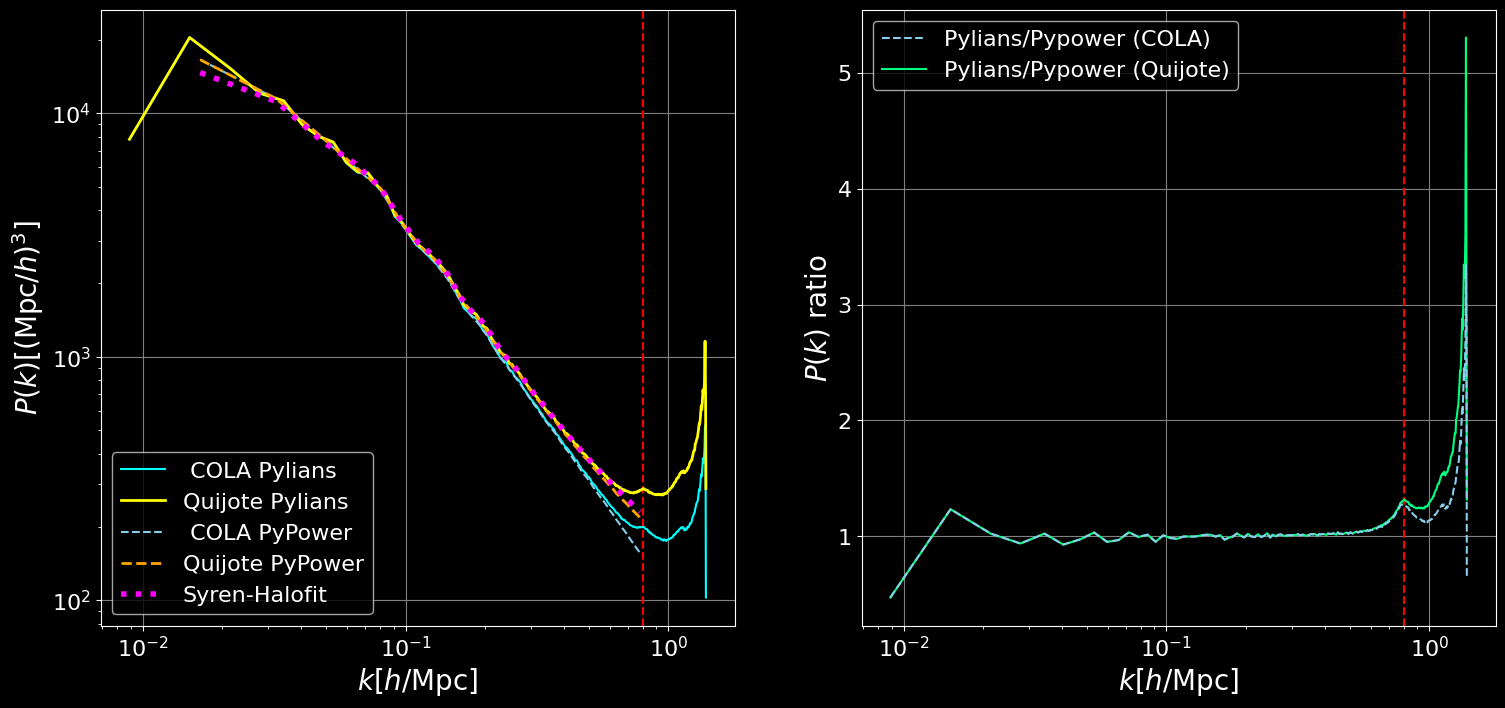

In [21]:
fig, axes = plt.subplots(figsize = (18,8), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm_alt, Pk_pm_alt, label=" COLA Pylians", zorder = 3, color = "cyan")
ax1.plot(k_nb_alt, Pk_nb_alt, label='Quijote Pylians', lw = 2, color = "yellow", zorder = 4)
ax1.plot(k_pm, Pk_pm, label=" COLA PyPower", zorder = 3, color = "skyblue", ls = "--")
ax1.plot(k_nb, Pk_nb, label='Quijote PyPower', lw = 2, color = "orange", zorder = 4, ls = "--")
ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit', color = "magenta", ls = "dotted", zorder = 8, lw = 4)
ax1.legend(fontsize = 16)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 20)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 20)
ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax1.tick_params(labelsize = 16)

ax2.plot(k_pm_alt, Pk_pm_alt/np.interp(k_pm_alt, k_pm, Pk_pm),label='Pylians/Pypower (COLA)', zorder = 5, color = "skyblue", ls = "--")
ax2.plot(k_nb_alt, Pk_nb_alt/np.interp(k_nb_alt, k_nb, Pk_nb),label='Pylians/Pypower (Quijote)', zorder = 4, color = "springgreen")
#ax2.plot(k_pm, Pk_pm/poles_pm(k=k_pm, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 4, color = "crimson", ls = "--")
#ax2.plot(k_nb, Pk_nb/poles_nb(k=k_nb, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 3, color = "springgreen")
ax2.legend(fontsize = 16)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 20)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 20)
ax2.grid(color = "grey")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax2.tick_params(labelsize = 16)
plt.savefig(os.path.join(figroot, "initial_power_spectra.pdf"), bbox_inches = "tight")

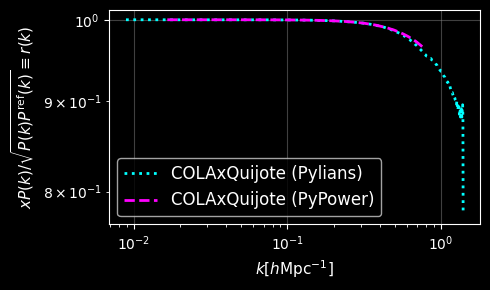

In [22]:
nbint = np.interp(k_X, k_nb_raw, Pk_nb_raw)
pmint = np.interp(k_X, k_pm_raw, Pk_pm_raw)

fig, axes = plt.subplots(1,1, figsize = (5,3))
axes.plot(k_X_alt, rk_alt, ':', label='COLAxQuijote (Pylians)', zorder= 10, lw = 2, color = "cyan")
#axes.plot(k_X, Pk_X/np.sqrt(Pk_nb*Pk_pm), '--', label='COLAxQuijote (PyPower)', zorder= 10, lw = 2, color = "magenta")
axes.plot(k_X, Pk_X/np.sqrt(nbint*pmint), '--', label='COLAxQuijote (PyPower)', zorder= 10, lw = 2, color = "magenta")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_pm_nbody.pdf"), bbox_inches = "tight")

# 2) Dark matter particles - perfect correlation case

$\Phi(k) = \frac{\gamma_k}{k^2} \Delta_k$


If we take the expectation with respect to Delta, power spectrum, as well as bispectum and trispectrum terms appear

\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} &\approx \frac{P(k)}{V} + \gamma_k^2\frac{P(k)}{V} +\sum_{\mathbf{q},\mathbf{q'}} \frac{\gamma_{q'}\gamma_{q}}{q^2 q'^{2}}(\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}
 \Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast}] \nonumber \\
&+ 2 \operatorname{Re}\left[  \gamma_k \frac{P(k)}{V} + \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \gamma_k \frac{\gamma_q}{q^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}] \right. \nonumber \\
 &+\left. \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}]
    +\frac{1}{2} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot (\mathbf{k} -\mathbf{q}))\frac{\gamma_q}{q^2} \frac{\gamma_{|k-q|}}{|k-q|^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{k-q}}^{\ast}]
 \right. \nonumber \\
 &+ \left. \frac{1}{2} \sum_{\mathbf{q}, \mathbf{q'}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot \mathbf{q'})\frac{\gamma_q}{q^2} \frac{\gamma_q'}{q'^2}\mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast}] \right]
\end{align}
**Question**

Can we afford dropping bispectrum and trispectrum terms and simply solving for the polynomial below ? 
\begin{equation}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} = P(k) + \gamma_k^2 P(k) + 2 \gamma_k P(k) 
\end{equation}

## 2-1) With only the second-order system above


In [23]:
# If emulator, the target Power spectrum is a mean emulator calculation
emulator = False
Pk_target = pk_syrenhalofit if emulator else Pk_nb

high_roots = True # take roots_e[:,1].real if True, roots_e[:,0].real otherwise

tstr = "emul" if emulator else "sim"
rstr = "posroots" if high_roots else "negroots"

fig_fold = os.path.join(basedir, appstr, "corr_%s_%s"%(tstr, rstr))

if not os.path.exists(fig_fold):
    os.makedirs(os.path.join(fig_fold), exist_ok=False)

# Limit the analysis to k Nyquist
kN = np.pi *grid/BoxSize
#kN = k_nb.max()
inds = np.where(k_nb <= kN)
k = k_nb[inds]
inds_alt = np.where(k_nb_alt <= kN)
k_alt = k_nb_alt[inds_alt]
print(k.shape, k_nb.shape)

(48,) (48,)


(48, 3)


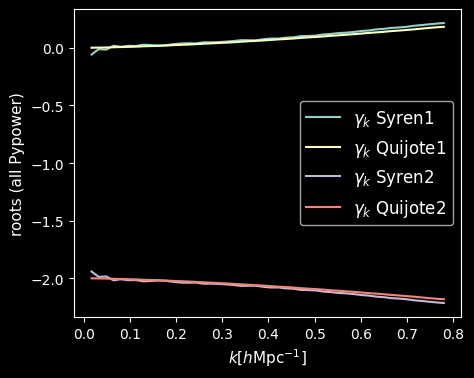

In [24]:
# With gamma convention
roots_nb, coeffs_nb=get_roots_gamma(k, Pk_pm[inds], Pk_nb[inds])
roots_nb_alt, coeffs_nb_alt=get_roots_gamma(k_alt, Pk_pm_alt[inds_alt], Pk_nb_alt[inds_alt])
roots_e, coeffs_e=get_roots_gamma(k, Pk_pm[inds], pk_syrenhalofit[inds])

# "Positive" roots
gamma_k_e1 = roots_e[:,1].real
gamma_k_nb1 = roots_nb[:,1].real
gamma_k_nb1_alt = roots_nb_alt[:,1].real

# "Lower" roots
gamma_k_e2 = roots_e[:,0].real
gamma_k_nb2 = roots_nb[:,0].real
print(coeffs_e.shape)

fig, ax = plt.subplots(figsize = (5,4), ncols = 1, nrows= 1)
ax.plot(k, gamma_k_e1, label=r'$\gamma_k$' + " Syren1")
ax.plot(k, gamma_k_nb1, label=r'$\gamma_k$' + " Quijote1")
ax.plot(k, gamma_k_e2, label=r'$\gamma_k$' + " Syren2")
ax.plot(k, gamma_k_nb2, label=r'$\gamma_k$' + " Quijote2")
ax.legend(fontsize = 12)
ax.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
ax.set_ylabel(r"roots (all Pypower)", fontsize = 11)
#plt.tight_layout()
plt.savefig(os.path.join(fig_fold, "gammak_roots.pdf"), bbox_inches = "tight")

# Sets the roots for later with the same variable names
if emulator:
    Pk_target = pk_syrenhalofit
    gamma_k = gamma_k_e1 if high_roots else gamma_k_e2
    coeffs = coeffs_e
    roots = roots_e
else:
    Pk_target = Pk_nb
    gamma_k = gamma_k_nb1 if high_roots else gamma_k_nb2
    coeffs = coeffs_nb
    roots = roots_nb

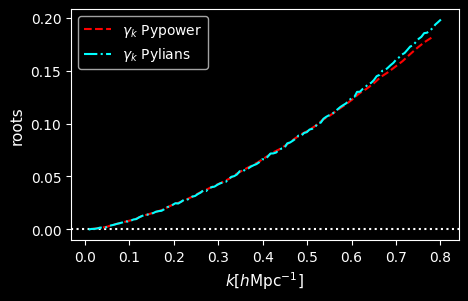

In [25]:
fig = plt.figure(figsize = (5,3))
plt.plot(k, roots_nb[:,1].real, label = r"$\gamma_k$" + " Pypower", ls = "--", zorder =3, color = "red")
plt.plot(k_alt, roots_nb_alt[:,1].real, label = r"$\gamma_k$" + " Pylians", ls = "dashdot", zorder =4, color = "cyan")
plt.legend(fontsize = 12)
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
plt.ylabel(r"roots", fontsize = 11)
plt.axhline(0, ls = "dotted")
# plt.loglog()
plt.legend()
plt.savefig(os.path.join(figroot, "correlatedcase_roots_1D.pdf"), bbox_inches = "tight")

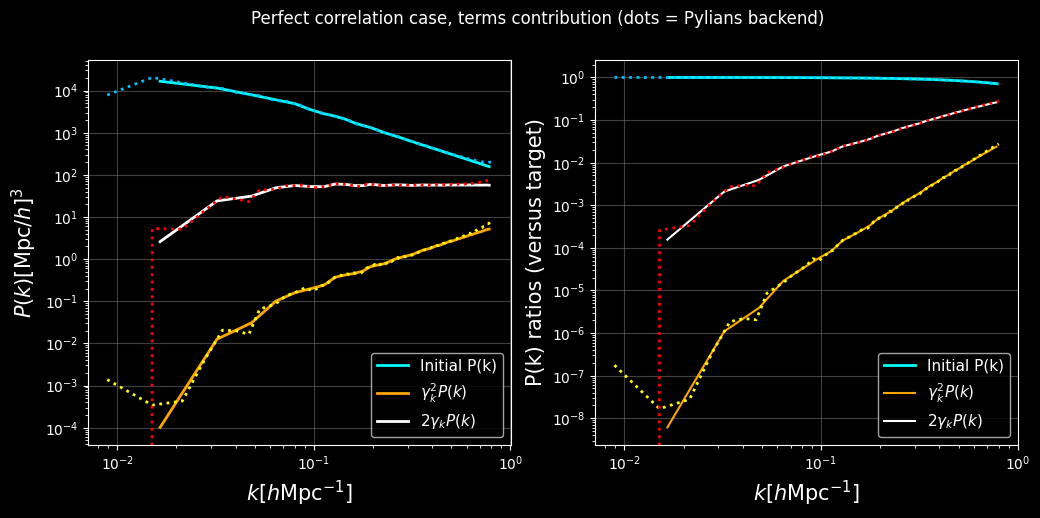

In [26]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

#ax1.plot(k, Pk_nb[inds], color = "magenta", lw = 2, label = "Target Quijote P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 2, label = "Initial P(k)", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 2, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 2, label = r"$2\gamma_k P(k)$")
ax1.plot(k_alt, Pk_pm_alt[inds_alt], color = "deepskyblue", lw = 2, zorder = 5, ls = ':')
ax1.plot(k_alt, coeffs_nb_alt[:,0]*(roots_nb_alt[:,1].real)**2, color = "yellow", lw = 2, ls = ':')
ax1.plot(k_alt, coeffs_nb_alt[:,1]*roots_nb_alt[:,1].real, color = "red", lw = 2, ls = ':')
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =15)
ax1.set_ylabel(r"$P(k)[\mathrm{Mpc}/h]^3$", fontsize =15)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

#ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", lw = 2, label = "Target Quijote P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "cyan", lw = 2, label = "Initial P(k)", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.plot(k_alt, Pk_pm_alt[inds_alt]/Pk_nb_alt[inds_alt], color = "deepskyblue", lw = 2, zorder = 5, ls=":")
ax2.plot(k_alt, coeffs_nb_alt[:,0]*(roots_nb_alt[:,1].real)**2/Pk_nb_alt[inds_alt], color = "yellow", lw = 2, ls=":")
ax2.plot(k_alt, coeffs_nb_alt[:,1]*roots_nb_alt[:,1].real/Pk_nb_alt[inds_alt], color = "red", lw = 2, ls=":")
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =15)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =15)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution (dots = Pylians backend)")
plt.savefig(os.path.join(figroot, "correlated_terms_contributions.pdf"), bbox_inches = "tight")

### With delta from Pypower! With MAS correction by hand.

In [27]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)
MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

# Put gamma_k weights in 3D
#weights1D = gamma_k
weights1D = gamma_k/k**2
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D, extra_right = 0.)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_mas = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_mas = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_mas = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

0.0 1.3929979117318794
True


In [28]:
print(gamma_k.min(),gamma_k.max())
print(weights1D.min(),weights1D.max())
print(weights_grid.min(), weights_grid.max())

7.8087183063565e-05 0.18132757215722897
0.2856106646912864 1.0108712248044995
0.0 1.0062336696295509


1.382115115546474
(221,)
(256,)


[None, None]

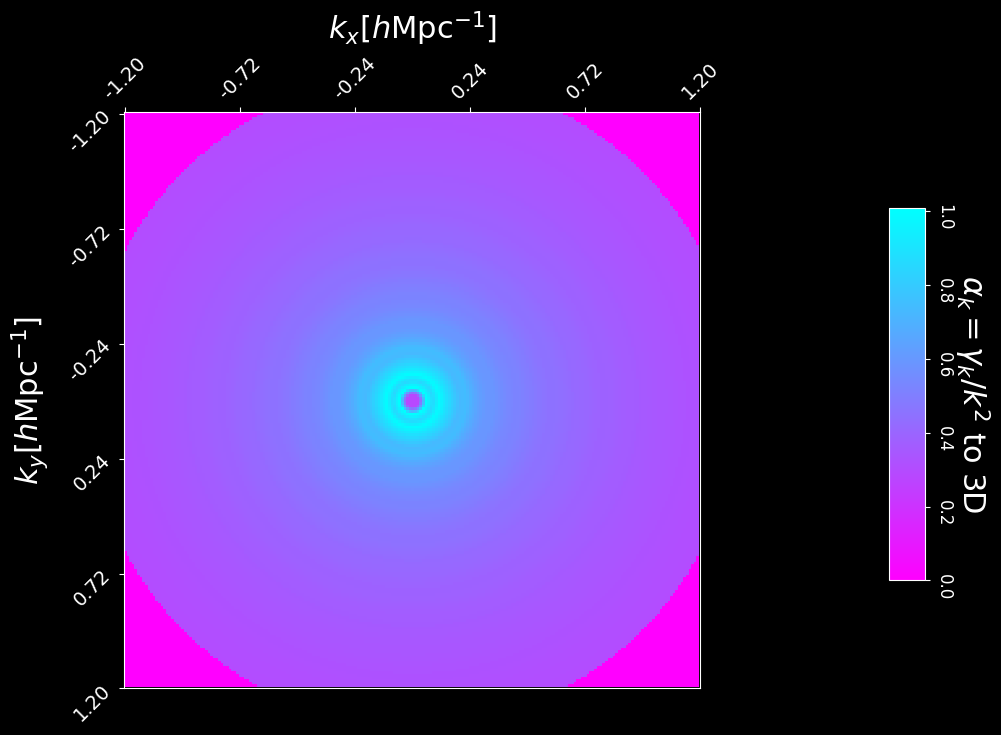

In [29]:
fig, ax1 = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 1, 
                         sharex = False, sharey = False)

div_cmap = cm.cool_r
div_cmap.set_bad('black',1.)
origin = "upper"

#kpl = kx_v*np.sqrt(3)
freq = np.fft.fftshift(np.fft.fftfreq(grid))
kpl = scale * freq * np.sqrt(3)
print(kpl.max())
kmip = -1.2
kmap = -kmip

fshift = True
indp = np.where((kpl>=kmip)&(kpl<=kmap))[0]
print(indp.shape)
print(kpl.shape)
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(freq)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(weights_grid[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(weights_grid[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(weights_grid[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = abs(weights_grid[:,:,indcut]).min(), vmax = abs(weights_grid[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
#cb.ax.minortickskN_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\alpha_k = \gamma_k/k^2$" + " to 3D", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
#ax1.set_title("With Halo code (np.digitize)", fontsize = 20)


### Without MAS correction by hand.

In [30]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

# Put gamma_k weights in 3D
#weights1D = gamma_k
weights1D = gamma_k/k**2
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D, extra_right = 0.)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_nomas = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_nomas = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_nomas = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

0.0 1.3929979117318794
True


0.18796867
0.12266957
10.766042
float32


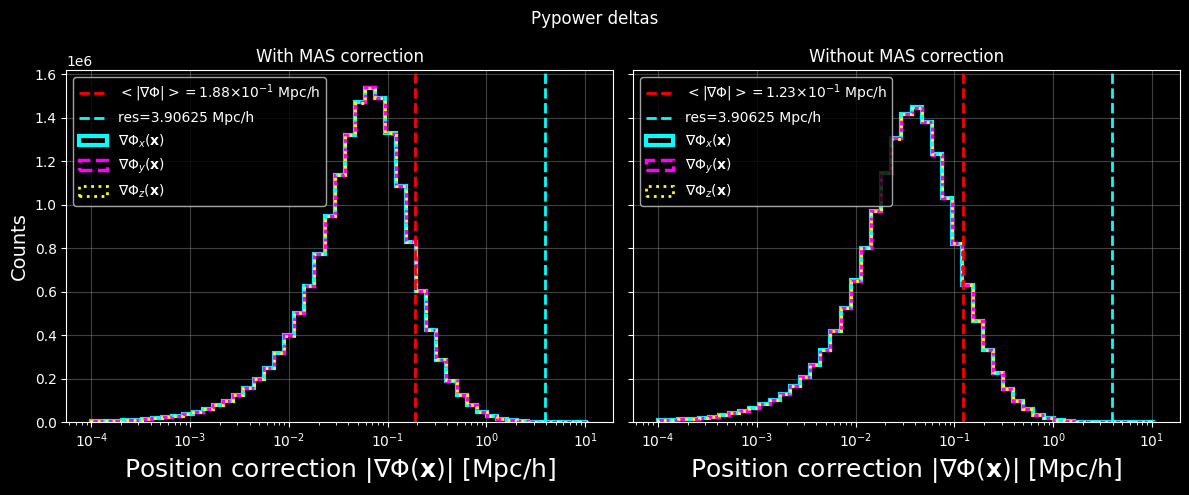

In [31]:
mean_dispmas = np.mean(np.sqrt(a_x_mas**2 + a_y_mas**2+a_z_mas**2 ))
mean_dispnomas = np.mean(np.sqrt(a_x_nomas**2 + a_y_nomas**2+a_z_nomas**2 ))
max_disp = max(np.sqrt(a_x_mas**2 + a_y_mas**2+a_z_mas**2 ).max(), np.sqrt(a_x_nomas**2 + a_y_nomas**2+a_z_nomas**2 ).max())
print(mean_dispmas)
print(mean_dispnomas)
print(max_disp)
print(a_x_mas.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, axes = plt.subplots(1,2, figsize = (12,5), sharey = True)
ax1 = axes[0]; ax2 = axes[1]
ax1.axvline(x = mean_dispmas,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_dispmas))
ax1.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax1.hist(np.abs(a_x_mas.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax1.hist(np.abs(a_y_mas.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax1.hist(np.abs(a_z_mas.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax1.set_xscale("log")
ax1.legend(fontsize = 10)
ax1.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax1.set_ylabel("density", fontsize = 14)
else:
    ax1.set_ylabel("Counts", fontsize = 14)
ax1.grid(color = "gray", alpha = 0.5)

ax2.axvline(x = mean_dispnomas,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_dispnomas))
ax2.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax2.hist(np.abs(a_x_nomas.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax2.hist(np.abs(a_y_nomas.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax2.hist(np.abs(a_z_nomas.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax2.set_xscale("log")
ax2.legend(fontsize = 10)
ax2.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)

ax2.grid(color = "gray", alpha = 0.5)
plt.suptitle("Pypower deltas")
ax1.set_title("With MAS correction")
ax2.set_title("Without MAS correction")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gradient_modulus_ditribution.pdf"), bbox_inches = "tight")
#ax.set_xlim(left = 0, right = 60.)

In [32]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected_mas= np.empty(pos_pm.shape).astype(prec_in)
pos_corrected_nomas= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected_mas, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_mas, a_x_mas.astype("float32"), a_y_mas.astype("float32"), a_z_mas.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

pos_corrected_nomas, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_nomas, a_x_nomas.astype("float32"), a_y_nomas.astype("float32"), a_z_nomas.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256


In [33]:
del nabla_x_i
get_ipython().displayhook.flush()
gc.collect()

0

In [34]:
recompbool = False
suffstr = "trunc"
if os.path.exists(os.path.join('precomps', "pypower_dispmas_%i_bins%s.npy"%(num_bins, suffstr))) and not recompbool:
    print("LOADING PYPOWER COMPUTATIONS")
    k_disp_mas = np.load(os.path.join('precomps', 'kdispmas_%i_bins%s.npy'%(num_bins, suffstr)))
    k_disp_nomas = np.load(os.path.join('precomps', 'kdispnomas_%i_bins%s.npy'%(num_bins, suffstr)))
    Pk_disp_mas = np.load(os.path.join('precomps', "pypower_dispmas_%i_bins%s.npy"%(num_bins, suffstr)))
    Pk_disp_nomas = np.load(os.path.join('precomps', "pypower_dispnomas_%i_bins%s.npy"%(num_bins, suffstr)))
    k_disp_masr = np.load(os.path.join('precomps', 'kdispmasr_%i_bins%s.npy'%(num_bins, suffstr)))
    k_disp_nomasr = np.load(os.path.join('precomps', 'kdispnomasr_%i_bins%s.npy'%(num_bins, suffstr)))
    Pk_disp_masr = np.load(os.path.join('precomps', "pypower_dispmasr_%i_bins%s.npy"%(num_bins, suffstr)))
    Pk_disp_nomasr = np.load(os.path.join('precomps', "pypower_dispnomasr_%i_bins%s.npy"%(num_bins, suffstr)))
    k_Xdisp = np.load(os.path.join('precomps', 'kXdispmas_%i_bins%s.npy'%(num_bins, suffstr)))
    Pk_Xdisp = np.load(os.path.join('precomps', "pypower_Xdispmas_%i_bins%s.npy"%(num_bins, suffstr)))
else:
    print("RUNNING PYPOWER COMPUTATIONS")
    start = time.time()
    result_mas = CatalogFFTPower(data_positions1=pos_corrected_mas, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    result_nomas = CatalogFFTPower(data_positions1=pos_corrected_nomas, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')

    result_Xdisp = CatalogFFTPower(data_positions1=pos_nb, data_positions2 = pos_corrected_mas, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    #result_pm.poles(remove_shotnoise=False)
    poles_mas = result_mas.poles
    poles_nomas = result_nomas.poles
    k_disp_mas, Pk_disp_mas = poles_mas(ell=ells, return_k=True, complex=False)
    k_disp_nomas, Pk_disp_nomas = poles_nomas(ell=ells, return_k=True, complex=False)

    # For cross coeffs
    k_disp_masr, Pk_disp_masr = poles_mas(ell=ells, return_k=True, complex=False, remove_shotnoise=False)
    k_disp_nomasr, Pk_disp_nomasr = poles_nomas(ell=ells, return_k=True, remove_shotnoise=False)

    np.save(os.path.join('precomps', 'kdispmas_%i_bins%s.npy'%(num_bins, suffstr)),k_disp_mas)
    np.save(os.path.join('precomps', 'kdispnomas_%i_bins%s.npy'%(num_bins, suffstr)),k_disp_nomas)
    np.save(os.path.join('precomps', "pypower_dispmas_%i_bins%s.npy"%(num_bins, suffstr)), Pk_disp_mas)
    np.save(os.path.join('precomps', "pypower_dispnomas_%i_bins%s.npy"%(num_bins, suffstr)), Pk_disp_nomas)
    np.save(os.path.join('precomps', 'kdispmasr_%i_bins%s.npy'%(num_bins, suffstr)),k_disp_masr)
    np.save(os.path.join('precomps', 'kdispnomasr_%i_bins%s.npy'%(num_bins, suffstr)),k_disp_nomasr)
    np.save(os.path.join('precomps', "pypower_dispmasr_%i_bins%s.npy"%(num_bins, suffstr)), Pk_disp_masr)
    np.save(os.path.join('precomps', "pypower_dispnomasr_%i_bins%s.npy"%(num_bins, suffstr)), Pk_disp_nomasr)

    poles_Xdisp = result_Xdisp.poles
    k_Xdisp, Pk_Xdisp = poles_Xdisp(ell=ells, return_k=True, complex=False)
    np.save(os.path.join('precomps', 'kXdispmas_%i_bins%s.npy'%(num_bins, suffstr)),k_Xdisp)
    np.save(os.path.join('precomps', "pypower_Xdispmas_%i_bins%s.npy"%(num_bins, suffstr)), Pk_Xdisp)

    end = time.time()
    print("%.2f seconds of computation for both pypower calculations"%(end-start))

LOADING PYPOWER COMPUTATIONS


In [35]:
k_disp_mas = k_disp_mas[~np.isnan(k_disp_mas)]
k_disp_nomas = k_disp_nomas[~np.isnan(k_disp_nomas)]
k_Xdisp = k_Xdisp[~np.isnan(k_Xdisp)]
Pk_disp_mas = Pk_disp_mas[~np.isnan(Pk_disp_mas)]
Pk_disp_nomas = Pk_disp_nomas[~np.isnan(Pk_disp_nomas)]
Pk_Xdisp = Pk_Xdisp[~np.isnan(Pk_Xdisp)]


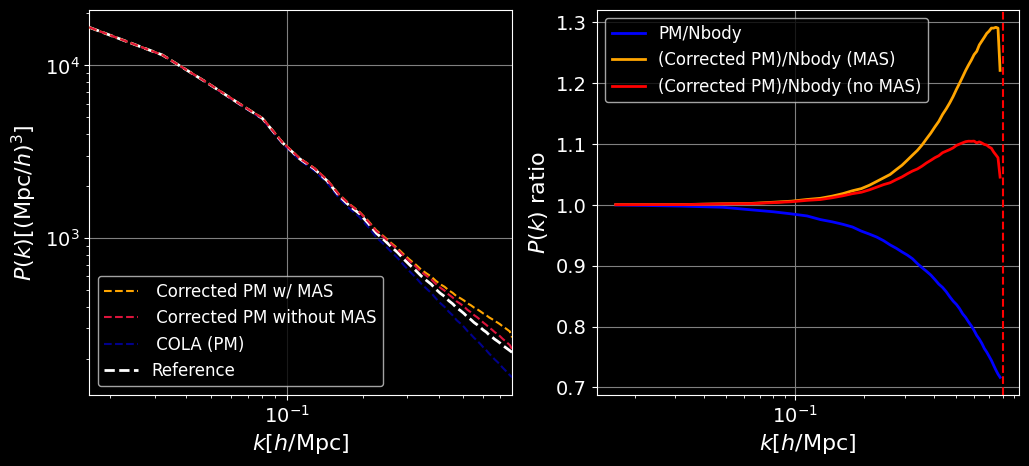

In [36]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
#ax1.plot(k_pm, Pk_pm, label=" COLA Pylians", zorder = 3, color = "cyan")
#ax1.plot(k_nb, Pk_nb, label='Quijote Pylians', lw = 2, color = "white", zorder = 4)
ax1.plot(k_disp_mas, Pk_disp_mas, label=" Corrected PM w/ MAS", zorder = 5, color = "orange", ls = "--")
ax1.plot(k_disp_nomas, Pk_disp_nomas, label=" Corrected PM without MAS", zorder = 5, color = "crimson", ls = "--")
ax1.plot(k_pm, Pk_pm, label=" COLA (PM)", zorder = 3, color = "darkblue", ls = "--")
ax1.plot(k_nb, Pk_nb, label='Reference', lw = 2, color = "white", zorder = 4, ls = "--")
#ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "dotted", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
#ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax1.tick_params(labelsize = 14)

#ko, Po = poles_pm(return_k=True, complex=False)
#kk, Pkk = poles_nb(complex = False, return_k = True)
#kcc, Pcc = poles_corr(complex = False, return_k = True)
#ax2.plot(k_pm, Pk_pm/poles_pm(k=k_pm, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 4, color = "crimson", ls = "--")
#ax2.plot(ko, Po[0,:]/Pk_nb, label='Corrected/Nbody', zorder = 3, color = "springgreen")
ax2.plot(k_nb, Pk_pm/Pk_nb, label='PM/Nbody', zorder = 3, color = "blue", lw=2)
ax2.plot(k_disp_mas, Pk_disp_mas/Pk_nb, label='(Corrected PM)/Nbody (MAS)', zorder = 3, color = "orange", lw = 2)
ax2.plot(k_disp_nomas, Pk_disp_nomas/Pk_nb, label='(Corrected PM)/Nbody (no MAS)', zorder = 3, color = "red", lw = 2)

ax2.legend(fontsize = 12)

ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax2.tick_params(labelsize = 14)
#x2.set_ylim(top = 1.05, bottom = 0.9)
ax1.set_xlim(left = k_disp_mas.min(), right =  k_disp_mas.max())
plt.savefig(os.path.join(figroot, "Pk_results_correlated_noBterm.pdf"), bbox_inches = "tight")

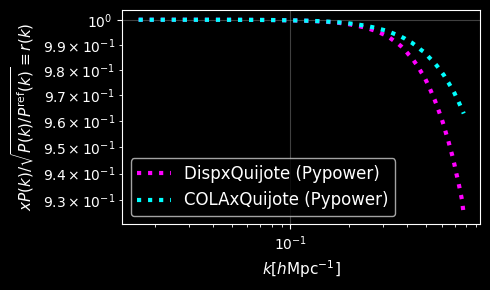

In [37]:
dispint = np.interp(k_Xdisp, k_disp_masr, Pk_disp_masr)

fig, axes = plt.subplots(1,1, figsize = (5,3))
axes.plot(k_Xdisp, Pk_Xdisp/np.sqrt(dispint*nbint), ':', label='DispxQuijote (Pypower)', zorder= 10, lw = 3, color = "magenta")
axes.plot(k_X, Pk_X/np.sqrt(nbint*pmint), ':', label='COLAxQuijote (Pypower)', zorder= 10, lw = 3, color = "cyan")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)/P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_disp_nbody.pdf"), bbox_inches = "tight")

## 2-2) Bispectrum computation

The system with the bispectrum term linear in gamma is 

\begin{align}
V\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} &\approx P(k) + \gamma_k^2 P(k) \nonumber \\
&+ 2 \gamma_k P(k) + \frac{2}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2} B(k,q, |\mathbf{k}-\mathbf{q}|)
\end{align}



Let's compute the term, with $|\mathbf{k}-\mathbf{q}| = \sqrt{k^2 + q^2 - 2kq \cos \theta}$,

\begin{equation}
     \text{"Bispectrum Term"}(k)  = \frac{2}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2} B(q,k, |\mathbf{k}-\mathbf{q}|)
\end{equation}.


First, we focus on the angular integral form, similarly to the uncorrelated case with $(\mathbf{k} \cdot \mathbf{q}) = k q \cos \theta$, where we compute the term J for k fixed:
<!-- \begin{align}
J(k,q) &= \int d\Omega_\mathbf{k} \int d\Omega_\mathbf{q} \, k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|) \nonumber \\
&=  \int_0^{2\pi} d\phi_k \int_0^{\pi} d\theta_k \sin \theta_k \int_0^{2\pi} d\phi_q \int_0^{\pi} d\theta_q \sin \theta_q k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|)\\
\end{align} -->

\begin{align}
J(k,q, \theta) &=  \int d\Omega_\mathbf{q} \, k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|) \nonumber \\
&=  \int_0^{2\pi} d\phi_q \int_0^{\pi} d\theta_q \sin \theta_q k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|)\\
\end{align}
The integrand only depends on the angle between the wavevectors and as for the previous demonstration, the integration over $\hat{\mathbf{q}}$ will give the same result for any fixed $\hat{\mathbf{k}}$. 
We can also choose $\hat{\mathbf{k}}$ along  
$\hat{\mathbf{z}}$ so that $\theta = \theta_q$

By isolating the integrand part than only depends on the angle between wavevectors, we get 
\begin{align}
J(k,q)&=  2\pi \frac{k}{q}\gamma_q  \int_0^{\pi} d\theta \sin \theta\cos \theta B(q,k,\sqrt{k^2 + q^2 - 2kq \cos \theta})\nonumber \\
&=2\pi \frac{k}{q}\gamma_q  \int_0^{\pi} -d(\cos \theta)\cos \theta B(q,k,\sqrt{k^2 + q^2 - 2kq \cos \theta})\nonumber \\
&=2\pi \frac{k}{q}\gamma_q  \int_{-1}^{1} y B(q,k,\sqrt{k^2 + q^2 - 2kq y})dy
\end{align}
with the change of variable $y = \cos \theta$.
WE integrate over $q^2dq$ for the radial part, being careful about the sum to integral factor in a periodic setup

\begin{align}
\text{"B. Term"}(k) &= \frac{2}{V}\sum_{\mathbf{q}} (\mathbf{k}\cdot\mathbf{q}) \frac{\gamma_q}{q^2}
B(k,q,|\mathbf{k}-\mathbf{q}|) \;\longrightarrow\; \frac{2}{(2\pi)^3}\int_0^{q_{\mathrm{max}}} q^2 J(k,q)\, dq \\
&= \frac{k}{2\pi^2} \int_0^{q_{\mathrm{max}}} q\, \gamma_q \left[\int_{-1}^1 y\, B(q,k,\sqrt{k^2+q^2-2kqy})\, dy\right] dq
\end{align}


**Note**: because I divided by $(2\pi)^3$ the equation to solve without the bispec term, I need to not include this factor in the total sum.

In [38]:
pb.PolyBin3D?

Init signature:
pb.PolyBin3D(
    boxsize,
    gridsize,
    Pk=None,
    boxcenter=None,
    pixel_window='none',
    backend='mkl',
    nthreads=None,
    sightline='global',
    real_fft=True,
)
Docstring:     
Base class for PolyBin3D.

Inputs:
- boxsize: 3D box-size (with 1 or 3 components)
- gridsize: Number of Fourier modes per dimension (with 1 or 3 components)
- Pk (optional): Fiducial power spectrum monopole (including noise), in ordering {k, P_0(k)}. This is used for the ideal estimators and for creating synthetic realizations for the optimal estimators. If unset, unit power will be assumed.
- boxcenter (optional): Center of the 3D box (with 1 or 3 components). Default: None ( = [0,0,0])
- pixel_window (optional): Which voxel window function to deconvolve from the data. See self.pixel_windows for a list of options (including "none"). Default: "none"
- backend (optional): Which backend to use to compute FFTs. Options: "mkl" [requires mkl_fft].   
- nthreads (optional): How ma

In [39]:
pb.BSpec?

Init signature:
pb.BSpec(
    base,
    k_bins,
    lmax=0,
    mask=None,
    applySinv=None,
    k_bins_squeeze=None,
    include_partial_triangles=False,
    add_GIC=False,
    mask_IC=None,
    add_RIC=False,
    radial_bins_RIC=[],
    Pk_fid=None,
    mask_shot=None,
    applySinv_transpose=None,
)
Docstring:     
Class containing the bispectrum estimators.

Inputs:
- base: PolyBin base class
- k_bins: array of one-dimensional k bin edges (e.g., [0.01, 0.02, 0.03] would give two bins: [0.01,0.02] and [0.02,0.03]).
- lmax: (optional) maximum Legendre multipole, default: 0.
- mask: (optional) 3D mask, specifying the background density n(x,y,z).
- applySinv: (optional) function which weights the data field. This is only used in unwindowed estimators.
- k_bins_squeeze: (optional) array of one-dimensional squeezed bin edges. These can be used to compute squeezed triangles, giving a different kmax for short and long sides.
- include_partial_triangles: (optional) whether to include tria


# Dimensions: [1.00e+03, 1.00e+03, 1.00e+03] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [256, 256, 256]
# Fundamental frequency: [0.0063, 0.0063, 0.0063] h/Mpc
# Nyquist frequency: [0.804, 0.804, 0.804] h/Mpc
# Pixel window: cic
# Using FFTW backend
5.6 seconds of computation
0.006283185307179587
0.016241800237438223
0.016241800237438223 0.00012741253100849494 0.016534941706515937 0.006283185307179587


Text(0, 0.5, 'np.diff(k)')

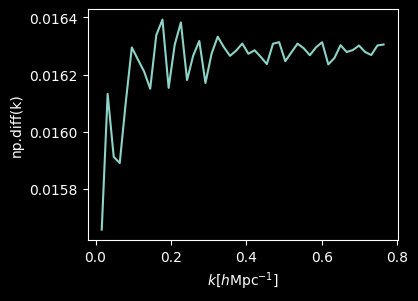

In [40]:
start = time.time()
base = pb.PolyBin3D([BoxSize,BoxSize,BoxSize], # dimensions of box 
                    [grid,grid,grid], # dimensions of Fourier-space grid, 
                    boxcenter=[0,0,0], # center of simulation box
                    pixel_window='cic', # pixel window function
                    backend='fftw', # backend for performing FFTs ('fftw' or 'mkl' for cpu, 'jax' for gpu)
                    nthreads=8, # number of CPUs to parallelize across (not used for jax code)
                    sightline='global') # redshift-space axis
end = time.time()
print("%.1f seconds of computation"%(end-start))

print(2*np.pi/1000) # delta_k
print(np.mean(np.diff(k)))
print(np.mean(np.diff(k_pm)),np.std(np.diff(k_pm)), k_pm[0], 2*np.pi/BoxSize)

A = plt.figure(figsize = (4,3))
plt.plot(k[:-1], np.diff(k))
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 10)
plt.ylabel("np.diff(k)")


Binning: 48 bins in [0.006, 0.788] h/Mpc
l-max: 0
N_bins: 10100
Mask: constant
0.2 seconds of computation


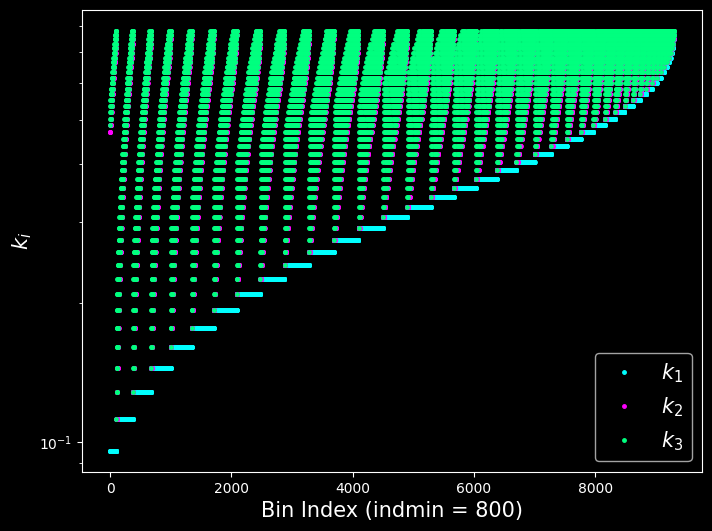

In [41]:
start = time.time()
down_factor = 1
#k_pm_edges = k_pm + np.mean(np.diff(k_pm))/2
k_down = kedges[::down_factor] # removing last k edge above k Nyquist

#dk_calc = np.mean(np.diff(k_down))
#k_edges = np.concatenate((k_down - 0.5*dk_calc,[k_down[-1] + 0.5*dk_calc]))
bspec = pb.BSpec(base, 
                 k_down, # k-bin edges
                 lmax=0
                )
end = time.time()
print("%.1f seconds of computation"%(end-start))

# Plot k-bins
indmin = 800
indmax = -1
k123 = bspec.get_ks()[:,indmin:indmax]
A = plt.figure(figsize = (8,6))
colors3 = ["cyan", "magenta", "springgreen"]
for i in range(3):
    plt.plot(k123[i],label=r'$k_%d$'%(i+1), ls = "None", marker = ".", markersize = 5, c= colors3[i])
plt.legend(fontsize=15);
plt.xlabel(r'Bin Index (indmin = %i)'%indmin,fontsize=15)
plt.ylabel(r'$k_i$',fontsize=15)
plt.xscale("linear")
plt.yscale("log")
plt.savefig(os.path.join(figroot, "polybin_bins3D.pdf"), bbox_inches = "tight")

In [42]:
bspec.Bk_ideal?

Signature:
bspec.Bk_ideal(
    data,
    fish_ideal=[],
    discreteness_correction=True,
    verb=False,
)
Docstring:
Compute the (normalized) idealized bispectrum estimator, weighting by 1/P_fid(k) within each bin. 

The estimator does *not* use the mask or S_inv weighting schemes (except for normalizing by < mask^3 >, and does not remove the linear term (which vanishes under ideal circumstances)

We optionally include 
discreteness corrections for ell>0.

This can compute the ideal bispectrum of simulation volumes, or, for suitably normalized input, the FKP power spectrum.
File:      ~/miniconda3/envs/pkcorr/lib/python3.10/site-packages/PolyBin3D/bspec.py
Type:      method

In [43]:
recompbisp = False

if os.path.exists(os.path.join("precomps","bk_uncorr_pm_bins%i_down%i.npy"%(num_bins,down_factor))) and not recompbisp:
    print("LOADING COMPUTATIONS")
    bk_uncorr = np.load(os.path.join("precomps","bk_uncorr_pm_bins%i_down%i.npy"%(num_bins,down_factor)))
    ks = np.load(os.path.join("precomps","bk_bins_pm_bins%i_down%i.npy"%(num_bins,down_factor)))
else:
    start = time.time()
    bk_uncorr = bspec.Bk_ideal(delta_pm, discreteness_correction=False)
    print(bk_uncorr.keys())
    end = time.time()
    print("%.1f seconds of computation"%(end-start))

    ks = bspec.get_ks()
    print(len(np.unique(ks[0,:])))

    bk_uncorr = bk_uncorr["b0"]
    np.save(os.path.join("precomps","bk_uncorr_pm_bins%i_down%i.npy"%(num_bins,down_factor)),bk_uncorr)
    np.save(os.path.join("precomps","bk_bins_pm_bins%i_down%i.npy"%(num_bins,down_factor)),ks)
# roughly 7-8 minutes of computation with a downsampling rate of 2
print(ks.shape)
k1_vals = np.unique(ks[0,:])
n_bk = len(k1_vals)
print(k1_vals)

LOADING COMPUTATIONS
(3, 10100)
[0.01442568 0.03071067 0.04699566 0.06328065 0.07956564 0.09585063
 0.11213562 0.12842061 0.1447056  0.16099059 0.17727559 0.19356058
 0.20984557 0.22613056 0.24241555 0.25870054 0.27498553 0.29127052
 0.30755551 0.3238405  0.34012549 0.35641048 0.37269547 0.38898046
 0.40526545 0.42155044 0.43783543 0.45412042 0.47040541 0.4866904
 0.5029754  0.51926039 0.53554538 0.55183037 0.56811536 0.58440035
 0.60068534 0.61697033 0.63325532 0.64954031 0.6658253  0.68211029
 0.69839528 0.71468027 0.73096526 0.74725025 0.76353524 0.77982023]


(48,) (49,)


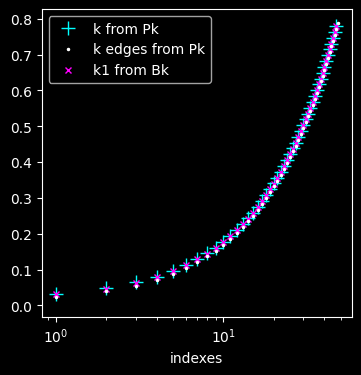

In [44]:
print(k1_vals.shape, k_down.shape)
plt.figure(figsize = (4,4))
plt.plot(k_pm[::down_factor], ls = "None", marker = "+", markersize = 10, color = "cyan", label = "k from Pk")
plt.plot(k_down, ls = "None", marker = ".", markersize = 3, 
         color = "white", label = "k edges from Pk", zorder= 3)
plt.plot(k1_vals, ls = "None", marker = "x", markersize = 5, color = "magenta", label = "k1 from Bk", zorder = 2)
plt.xlabel("indexes")
plt.legend()
plt.xscale("log")

## 2-3) Bispectrum Term contribution ?
We will be studying the remaining term that is linear in $\gamma_k$.

**IMPORTANT**: This contribution is when using the $\gamma$ solution from the Pk only polynomial, for intuition. 


With the conjugate-symmetry property for the FT of a real-valued field $\Delta (\mathbf{x})$, we have 

\begin{equation}
\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} = \Delta_{\mathbf{-q}}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{q-k}}}\,,
\end{equation}
so that when we take the expectation over $\Delta$ and sum over $q$, the contribution is non-zero because $-q+k+k-q$ always forms a closed triangle.


**Changes 22nd of June**

k3 selection: added mask = (k2_all == k2) so the inner y/bispectrum sum only uses the triplets actually paired with the current k2, instead of all k3 values across all k2 for this k1.
y sorting: np.trapz needs monotonic x; the BSpec output isn't guaranteed sorted in y, so we add np.argsort(y_arr).
Normalization: replaced 2*np.power(1./BoxSize,3) (i.e. 2/V) with 1./(4*np.pi**3) (i.e. 2/(2π)³), matching the corrected derivation — no BoxSize dependence coming from the sum to integral in periodic setup
Also deduplicated k2_vals via np.unique so the outer radial integral isn't computed redundantly over repeated q values.

In [45]:
start = time.time()
# Interpolator for gamma_q intervening in downsampled B term
interp_gamma = interp1d(k, gamma_k, kind="linear",
                        bounds_error=False, fill_value=(0., gamma_k[-1]))

# Bispectrum initialization
B_term = np.zeros(k1_vals.shape)

# This first loop is for the Bispec term over values of k1=k
i1 = 0
for k1 in k1_vals:
    inds   = np.where(ks[0, :] == k1)[0]
    ks_k1  = ks[1:, inds]
    bk1    = bk_uncorr[inds]

    k2_all = ks_k1[0, :]
    k3_all = ks_k1[1, :]
    k2_vals = np.unique(k2_all)          # distinct q values for this k1

    # For the integral over radial part, ie q modulus at fixed k (eq 59)
    B_integrand = np.zeros(k2_vals.shape)

    # This second loop is for fixed k
    i2 = 0
    for k2 in k2_vals:

        mask   = (k2_all == k2)          # only the (k2, k3) triplets for THIS k2
        k3_sub = k3_all[mask]
        bk_sub = bk1[mask]

        y_arr = (k1**2 + k2**2 - k3_sub**2) / (2*k1*k2)   # cos(theta)
        order = np.argsort(y_arr)                          # trapz needs monotonic x
        J = np.trapz(y_arr[order] * bk_sub[order], y_arr[order])

        J *= 2*np.pi*k1/k2 * interp_gamma(k2)
        B_integrand[i2] = k2**2 * J
        i2 += 1

    B_term[i1] = np.trapz(B_integrand, k2_vals)
    i1 += 1

# Corrected sum-to-integral factor (no BoxSize -- see section 3 derivation): 2/(2*pi)^3
B_term *= 1. / (4 * np.pi**3)

end = time.time()
print("%.2f seconds of computation" % (end - start))


0.04 seconds of computation


In [46]:
print(B_term)

[ 0.00000000e+00 -5.85645874e+01 -1.03821806e+02 -1.29454592e+02
 -1.47102579e+02 -1.34173271e+02 -1.30997442e+02 -1.29053196e+02
 -1.25271152e+02 -1.14553941e+02 -1.05266075e+02 -9.97644434e+01
 -9.14395106e+01 -8.13316146e+01 -7.47782730e+01 -6.67234926e+01
 -5.92792186e+01 -5.07490086e+01 -4.36396030e+01 -3.54659639e+01
 -2.75257723e+01 -2.03490542e+01 -1.30288538e+01 -5.59644983e+00
  1.07440362e+00  5.88032858e+00  8.94137455e+00  1.07129834e+01
  1.14782320e+01  1.16503509e+01  1.11918363e+01  1.03981849e+01
  9.50337290e+00  8.41688350e+00  7.32476398e+00  6.29140917e+00
  5.24804263e+00  4.30084387e+00  3.47233022e+00  2.71087497e+00
  2.04342889e+00  1.48433139e+00  1.00802976e+00  6.31009917e-01
  3.44422532e-01  1.50267587e-01  3.64434132e-02  0.00000000e+00]


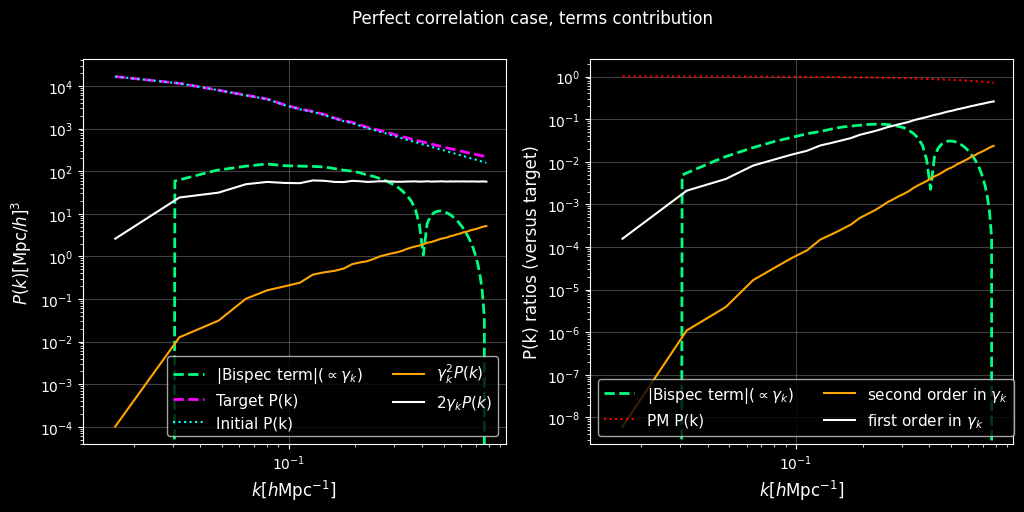

In [47]:
inds = np.where(k_nb <= kN)
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k1_vals, abs(B_term), color = "springgreen", ls = "--", lw = 2, label = "|Bispec term|" + r"($\propto \gamma_k$)")
ax1.plot(k_nb, Pk_nb, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k_pm, Pk_pm, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k_nb, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k_nb, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax1.set_ylabel(r"$P(k)[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11, ncols = 2)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

interp_pknb = interp1d(k, Pk_nb[inds], fill_value="extrapolate")

ax2.plot(k1_vals, abs(B_term)/interp_pknb(k1_vals), color = "springgreen", ls = "--", lw = 2, label = "|Bispec term|"+ r"$(\propto \gamma_k)$")
#ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "red", lw = 1.5, label = "PM P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = "second order in " + r"$\gamma_k$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = "first order in " + r"$\gamma_k$")
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11, ncols = 2)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")
plt.savefig(os.path.join(figroot, "correlated_terms_contributions_Bk.pdf"), bbox_inches = "tight")

In [48]:
k==k_nb

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [49]:
print(ks[0,:].min(),ks[0,:].max())
print(ks[1,:].min(),ks[1,:].max())
print(ks[2,:].min(),ks[2,:].max())
print(k_pm.min(), k_pm.max())
print(kedges.min(), kedges.max())

0.01442568055219803 0.7798202335839317
0.01442568055219803 0.7798202335839317
0.01442568055219803 0.7798202335839317
0.016534941706515937 0.7798995528661125
0.006283185307179587 0.7879627288289501


## 2-3) Linear system with Bispectrum
\begin{equation}
     \text{"Bispectrum Term"}(k) = \frac{2}{(2\pi)^3} \int_0^{q=k_{\mathrm{max}}} q^2 J(k,q)\,dq = \frac{k}{2\pi^2} \int_0^{q=k_{\mathrm{max}}} q\,\gamma_{q} \left[\int_{-1}^{1} y\, B(k,q,\sqrt{k^2 + q^2 - 2kq y})\,dy\right] dq
\end{equation}

To have a linear system, we discretize the integral over $q$ as a sum with quadrature weights $\Delta q_j$:

\begin{equation}
     \text{"Bispectrum Term"}(k_i) = \sum_j \frac{k_i}{2\pi^2}\, q_j\,\gamma_{q_j} \left[\int_{-1}^{1} y\, B(k_i,q_j,\sqrt{k_i^2 + q_j^2 - 2k_iq_j y})\,dy\right] \Delta q_j
\end{equation}

\begin{equation}
     \text{"B Matrix"}(k_i,q_j) = \frac{k_i}{2\pi^2}\, q_j \left[\int_{-1}^{1} y\, B(k_i,q_j,\sqrt{k_i^2 + q_j^2 - 2k_iq_j y})\,dy\right] \Delta q_j
\end{equation}

so that $\text{"Bispectrum Term"}(k_i) = \sum_j \text{"B Matrix"}(k_i,q_j)\,\gamma_{q_j}$, i.e. a matrix-vector product.

**Hassle, solved**: for each $k_1$ in the bispectrum output, the set of valid $k_2$ values differs (triangle-inequality constraints), so the BSpec triplets don't naturally form a square table. We resolve this by running BSpec with the *same* `kedges` as pypower, so its $k_1, k_2$ bin centers land exactly on the pypower $k$-grid. The "B Matrix" is then built directly on that common $n_k \times n_k$ grid via an index lookup ($k \to$ array position), leaving an entry at zero whenever no valid triangle exists for that $(k_i, q_j)$ pair — no interpolation needed, and the matrix size is fixed regardless of how many triangles BSpec actually returns per $k_1$.



In [50]:
def build_bispectrum_matrix(k, ks, bk):
    """
    Build M such that B_term(k_i) = sum_j M[i,j] * gamma[j].

    Parameters
    ----------
    k       : (n_k,)   pypower k-bin centers [h/Mpc]
    ks      : (3, N)   BSpec k-triplets [k1, k2, k3]
    bk      : (N,)     bispectrum values B(k1, k2, k3)

    Returns
    -------
    M : (n_k, n_k)
    """
    n_k = len(k)

    def k_to_idx(k_val):
        return np.argmin(np.abs(k - k_val))

    # Step 1: I_inner[i,j] = integral_y  y * B(k_j, k_i, k3(y)) dy
    I_inner = np.zeros((n_k, n_k))

    for k1 in np.unique(ks[0, :]):
        i        = k_to_idx(k1)
        sel      = np.where(ks[0, :] == k1)[0]
        k2_all   = ks[1, sel]
        k3_all   = ks[2, sel]
        bk_all   = bk[sel]

        for k2 in np.unique(k2_all):
            j        = k_to_idx(k2)
            mask     = (k2_all == k2) # entries for this (k1, k2) pair
            k3_sub   = k3_all[mask]
            bk_sub   = bk_all[mask]

            y_sub    = (k1**2 + k2**2 - k3_sub**2) / (2 * k1 * k2)
            order    = np.argsort(y_sub)
            I_inner[i, j] = np.trapz(y_sub[order] * bk_sub[order], y_sub[order])

    # Step 2: trapz weights for the outer integral over k_j, by hand
    dk        = np.empty(n_k)
    dk[1:-1]  = (k[2:] - k[:-2]) / 2
    dk[0]     = (k[1]  - k[0])   / 2
    dk[-1]    = (k[-1] - k[-2])  / 2

    # Step 3: M[i,j] = (4π/V) * k_i * k_j * I_inner[i,j] * dk_j
    #M = (4 * np.pi / BoxSize**3) * k[:, np.newaxis] * k[np.newaxis, :] * I_inner * dk[np.newaxis, :]

    # Correction with the sum integral convention ∑_q F(q) → (V/(2π)³)∫F(q)d³q (22nd of June 2026)
    M = (1 / (2*np.pi**2)) * k[:, np.newaxis] * k[np.newaxis, :] * I_inner * dk[np.newaxis, :]


    return M

M        = build_bispectrum_matrix(k, ks, bk_uncorr)
A        = 2 * np.diag(Pk_pm) + M
gamma_sol = np.linalg.solve(A, Pk_target - Pk_pm)
#B_term_sol = Pk_pm + 2 * gamma_sol * Pk_pm + B_term*gamma_sol

B_term_sol = M @ gamma_sol
P_reconstructed = Pk_pm + 2 * gamma_sol * Pk_pm + B_term_sol

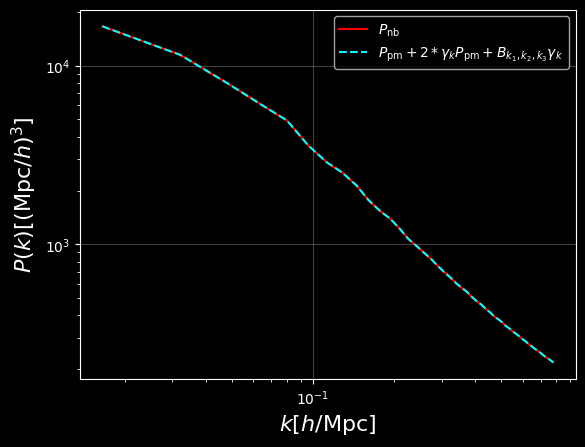

In [51]:
A = plt.figure()
plt.loglog(k_nb, Pk_nb, color = "red", label = r"$P_{\mathrm{nb}}$")
plt.loglog(k_pm, P_reconstructed, color = "cyan", ls = "--", label = r"$P_{\mathrm{pm}} + 2*\gamma_{k}P_{\mathrm{pm}} + B_{k_1,k_2,k_3}\gamma_{k}$")
plt.legend()
plt.xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
plt.ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
plt.grid(color = "grey", alpha = 0.5)

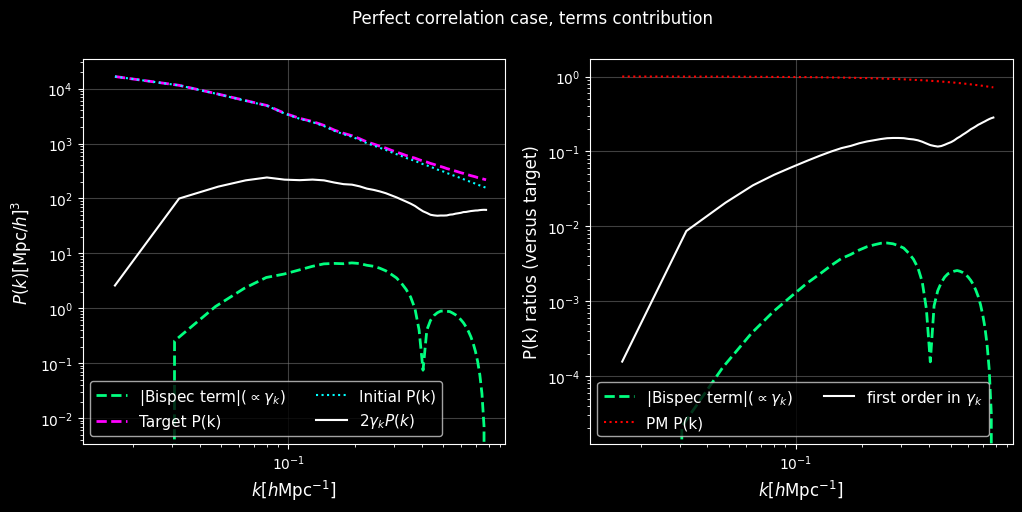

In [52]:
inds = np.where(k_nb <= kN)
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k1_vals, abs( B_term*gamma_sol), color = "springgreen", ls = "--", lw = 2, label = "|Bispec term|" + r"($\propto \gamma_k$)")
ax1.plot(k_nb, Pk_nb, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k_pm, Pk_pm, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
#ax1.plot(k_pm, Pk_pm*gamma_sol**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k_pm,2*gamma_sol*Pk_pm, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax1.set_ylabel(r"$P(k)[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11, ncols = 2)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

interp_pknb = interp1d(k, Pk_nb[inds], fill_value="extrapolate")

ax2.plot(k1_vals, abs( B_term*gamma_sol)/interp_pknb(k1_vals), color = "springgreen", ls = "--", lw = 2, label = "|Bispec term|"+ r"$(\propto \gamma_k)$")
#ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "red", lw = 1.5, label = "PM P(k)", ls = "dotted", zorder = 5)
#ax2.plot(k, Pk_pm*gamma_sol**2/Pk_nb[inds], color = "orange", lw = 1.5, label = "second order in " + r"$\gamma_k$")
ax2.plot(k, 2*gamma_sol*Pk_pm/Pk_nb[inds], color = "white", lw = 1.5, label = "first order in " + r"$\gamma_k$")
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11, ncols = 2)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")
plt.savefig(os.path.join(figroot, "correlated_terms_contributions_BkLinear.pdf"), bbox_inches = "tight")

In [53]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)
MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

# Put gamma_k weights in 3D
#weights1D = gamma_k
weights1D = gamma_sol/k**2
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D, extra_right = 0.)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_mas = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_mas = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_mas = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

0.0 1.3929979117318794
True


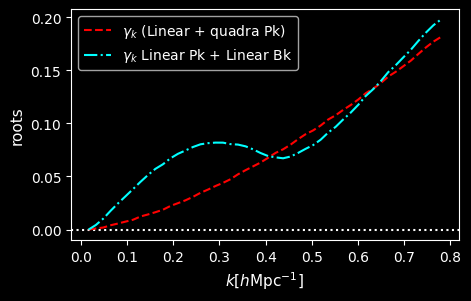

In [54]:
fig = plt.figure(figsize = (5,3))
plt.plot(k,gamma_k, label = r"$\gamma_k$" + " (Linear + quadra Pk)", ls = "--", zorder =3, color = "red")
plt.plot(k, gamma_sol, label = r"$\gamma_k$" + " Linear Pk + Linear Bk", ls = "dashdot", zorder =4, color = "cyan")
plt.legend(fontsize = 12)
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
plt.ylabel(r"roots", fontsize = 11)
plt.axhline(0, ls = "dotted")
# plt.loglog()
plt.legend()

In [55]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

# Put gamma_k weights in 3D
#weights1D = gamma_k
weights1D = gamma_sol/k**2
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D, extra_right = 0.)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_nomas = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_nomas = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_nomas = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

0.0 1.3929979117318794
True


1.382115115546474
(221,)
(256,)


[None, None]

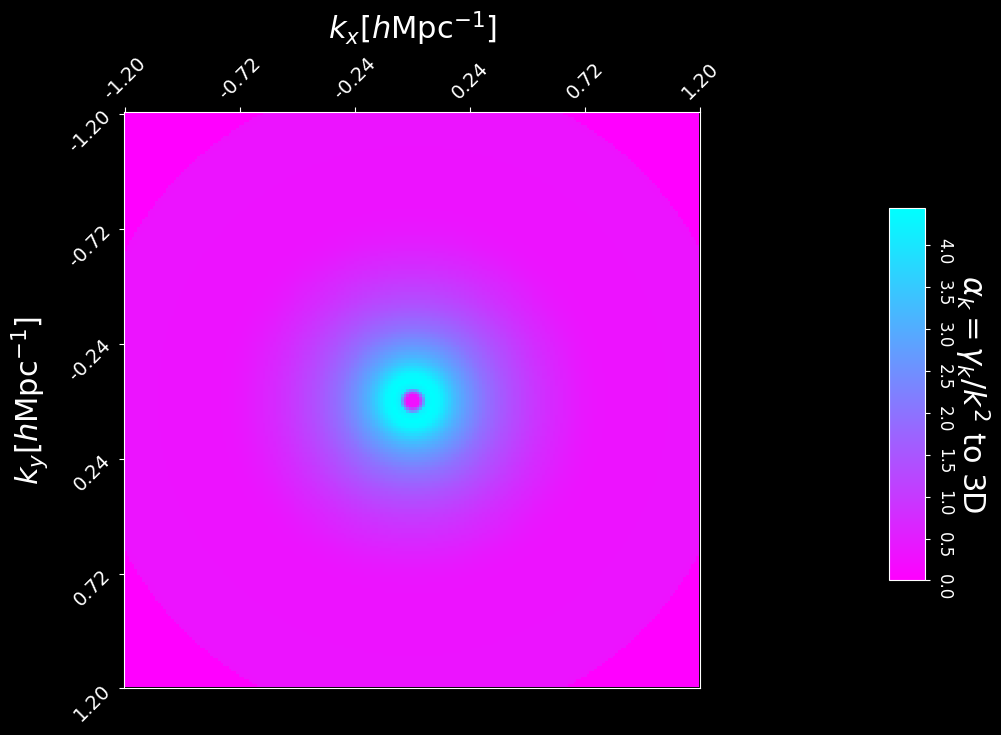

In [56]:
fig, ax1 = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 1, 
                         sharex = False, sharey = False)

div_cmap = cm.cool_r
div_cmap.set_bad('black',1.)
origin = "upper"

#kpl = kx_v*np.sqrt(3)
freq = np.fft.fftshift(np.fft.fftfreq(grid))
kpl = scale * freq * np.sqrt(3)
print(kpl.max())
kmip = -1.2
kmap = -kmip

fshift = True
indp = np.where((kpl>=kmip)&(kpl<=kmap))[0]
print(indp.shape)
print(kpl.shape)
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(freq)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(weights_grid[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(weights_grid[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(weights_grid[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = abs(weights_grid[:,:,indcut]).min(), vmax = abs(weights_grid[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
#cb.ax.minortickskN_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\alpha_k = \gamma_k/k^2$" + " to 3D", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
#ax1.set_title("With Halo code (np.digitize)", fontsize = 20)


In [57]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected_mas= np.empty(pos_pm.shape).astype(prec_in)
pos_corrected_nomas= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected_mas, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_mas, a_x_mas.astype("float32"), a_y_mas.astype("float32"), a_z_mas.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

pos_corrected_nomas, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_nomas, a_x_nomas.astype("float32"), a_y_nomas.astype("float32"), a_z_nomas.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256


In [58]:
recompbool = True
suffstr = "trunc"
if os.path.exists(os.path.join('precomps', "pypower_dispmas_%i_bins%s_lin.npy"%(num_bins, suffstr))) and not recompbool:
    print("LOADING PYPOWER COMPUTATIONS")
    k_disp_mas = np.load(os.path.join('precomps', 'kdispmas_%i_bins%s_lin.npy'%(num_bins, suffstr)))
    Pk_disp_mas = np.load(os.path.join('precomps', "pypower_dispmas_%i_bins%s_lin.npy"%(num_bins, suffstr)))
    k_disp_masr = np.load(os.path.join('precomps', 'kdispmasr_%i_bins%s_lin.npy'%(num_bins, suffstr)))
    Pk_disp_masr = np.load(os.path.join('precomps', "pypower_dispmasr_%i_bins%s_lin.npy"%(num_bins, suffstr)))
    #k_disp_nomas = np.load(os.path.join('precomps', 'kdispnomas_%i_bins%s_lin.npy'%(num_bins, suffstr)))
    #Pk_disp_nomas = np.load(os.path.join('precomps', "pypower_dispnomas_%i_bins%s_lin.npy"%(num_bins, suffstr)))
    #k_disp_nomasr = np.load(os.path.join('precomps', 'kdispnomasr_%i_bins%s_lin.npy'%(num_bins, suffstr)))
    #Pk_disp_nomasr = np.load(os.path.join('precomps', "pypower_dispnomasr_%i_bins%s_lin.npy"%(num_bins, suffstr)))
    k_Xdisp = np.load(os.path.join('precomps', 'kXdispmas_%i_bins%s_lin.npy'%(num_bins, suffstr)))
    Pk_Xdisp = np.load(os.path.join('precomps', "pypower_Xdispmas_%i_bins%s_lin.npy"%(num_bins, suffstr)))
else:
    print("RUNNING PYPOWER COMPUTATIONS")
    start = time.time()
    result_mas = CatalogFFTPower(data_positions1=pos_corrected_mas, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')

    #result_nomas = CatalogFFTPower(data_positions1=pos_corrected_nomas, boxsize=BoxSize, nmesh=grid, 
    #                            resampler= MAS.lower(),
    #                            edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')

    result_Xdisp = CatalogFFTPower(data_positions1=pos_nb, data_positions2 = pos_corrected_mas, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')


    #result_pm.poles(remove_shotnoise=False)
    poles_mas = result_mas.poles
    #poles_nomas = result_nomas.poles
    k_disp_mas, Pk_disp_mas = poles_mas(ell=ells, return_k=True, complex=False)
    #k_disp_nomas, Pk_disp_nomas = poles_nomas(ell=ells, return_k=True, complex=False)

    # For cross coeffs
    k_disp_masr, Pk_disp_masr = poles_mas(ell=ells, return_k=True, complex=False, remove_shotnoise=False)
    #k_disp_nomasr, Pk_disp_nomasr = poles_nomas(ell=ells, return_k=True, remove_shotnoise=False)
    
    #result_pm.poles(remove_shotnoise=False)
    #poles_mas = result_mas.poles
    #k_disp_mas, Pk_disp_mas = poles_mas(ell=ells, return_k=True, complex=False)

    # For cross coeffs
    #k_disp_masr, Pk_disp_masr = poles_mas(ell=ells, return_k=True, complex=False, remove_shotnoise=False)

    np.save(os.path.join('precomps', 'kdispmas_%i_bins%s_lin.npy'%(num_bins, suffstr)),k_disp_mas)
    np.save(os.path.join('precomps', "pypower_dispmas_%i_bins%s_lin.npy"%(num_bins, suffstr)), Pk_disp_mas)
    np.save(os.path.join('precomps', 'kdispmasr_%i_bins%s_lin.npy'%(num_bins, suffstr)),k_disp_masr)
    np.save(os.path.join('precomps', "pypower_dispmasr_%i_bins%s_lin.npy"%(num_bins, suffstr)), Pk_disp_masr)
    #np.save(os.path.join('precomps', 'kdispnomas_%i_bins%s_lin.npy'%(num_bins, suffstr)),k_disp_nomas)
    #np.save(os.path.join('precomps', "pypower_dispnomas_%i_bins%s_lin.npy"%(num_bins, suffstr)), Pk_disp_nomas)
    #np.save(os.path.join('precomps', 'kdispnomasr_%i_bins%s_lin.npy'%(num_bins, suffstr)),k_disp_nomasr)
    #np.save(os.path.join('precomps', "pypower_dispnomasr_%i_bins%s_lin.npy"%(num_bins, suffstr)), Pk_disp_nomasr)

    poles_Xdisp = result_Xdisp.poles
    k_Xdisp, Pk_Xdisp = poles_Xdisp(ell=ells, return_k=True, complex=False)
    np.save(os.path.join('precomps', 'kXdispmas_%i_bins%s_lin.npy'%(num_bins, suffstr)),k_Xdisp)
    np.save(os.path.join('precomps', "pypower_Xdispmas_%i_bins%s_lin.npy"%(num_bins, suffstr)), Pk_Xdisp)

    end = time.time()
    print("%.2f seconds of computation for both pypower calculations"%(end-start))

RUNNING PYPOWER COMPUTATIONS
272.23 seconds of computation for both pypower calculations


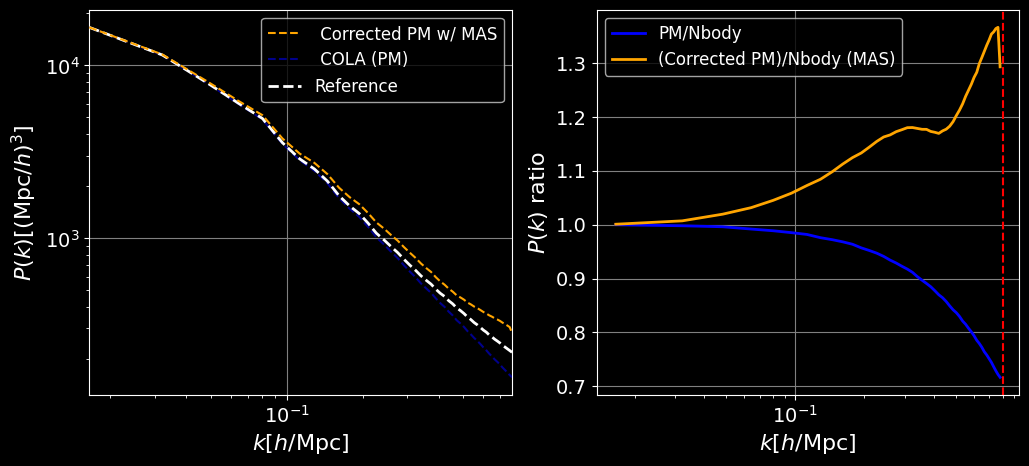

In [63]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
#ax1.plot(k_pm, Pk_pm, label=" COLA Pylians", zorder = 3, color = "cyan")
#ax1.plot(k_nb, Pk_nb, label='Quijote Pylians', lw = 2, color = "white", zorder = 4)
ax1.plot(k_disp_mas, Pk_disp_mas, label=" Corrected PM w/ MAS", zorder = 5, color = "orange", ls = "--")
ax1.plot(k_pm, Pk_pm, label=" COLA (PM)", zorder = 3, color = "darkblue", ls = "--")
ax1.plot(k_nb, Pk_nb, label='Reference', lw = 2, color = "white", zorder = 4, ls = "--")
#ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "dotted", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
#ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax1.tick_params(labelsize = 14)


ax2.plot(k_nb, Pk_pm/Pk_nb, label='PM/Nbody', zorder = 3, color = "blue", lw=2)
ax2.plot(k_disp_mas, Pk_disp_mas/Pk_nb, label='(Corrected PM)/Nbody (MAS)', zorder = 3, color = "orange", lw = 2)

ax2.legend(fontsize = 12)

ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax2.tick_params(labelsize = 14)
#x2.set_ylim(top = 1.05, bottom = 0.9)
ax1.set_xlim(left = k_disp_mas.min(), right =  k_disp_mas.max())
plt.savefig(os.path.join(figroot, "Pk_results_correlated_linearB.pdf"), bbox_inches = "tight")

## 2-4) Root finding with Bispectrum contribution
With all terms, including $\gamma^2$, we cannot resort to a linear system.

In [60]:
def bispectrum_term(gamma_vec, k_vec, ks_b, bk_monopole):
    '''
    ks is an instance of get_ks()
    '''
    k1_vals = np.unique(ks_b[0,:])
    n_bk = len(k1_vals)

    # Interpolator for gamma_q intervening in downsampled B term
    interp_gamma = interp1d(k_vec, gamma_vec, kind = "linear")

    # Bispectrum initialization
    B_term = np.zeros(k1_vals.shape)
    
    # This first loop is for the Bispec term over values of k1=k
    i1=0
    for k1 in k1_vals:
        inds = np.where(ks[0,:]==k1)[0]
        ks_k1 = ks[1:,inds]
        
        bk1 = bk_monopole[inds]
        #print(bk1.shape)
    
        k2_vals =  ks_k1[0,:]
        k3_vals =  ks_k1[1,:]
    
        # For the integral over radial part, ie q modulus at fixed k (eq 59)
        B_integrand = np.zeros(k2_vals.shape)
        
        #k2=q values are all distinct, and so are k3 values for fixesd k1=k
        # This second loop is for fixed k
        i2 = 0
        for k2 in k2_vals:
            
            J_integrand = np.zeros(k3_vals.shape)
            y_arr  = np.zeros(k3_vals.shape)
            
            # We are computing J(k,q) in this loop, ie a sum over k3 (eq 58)
            i3=0
            for k3 in k3_vals:
                
                y = (k1**2 + k2**2 - k3**2)/(2*k1*k2)# cos(theta)
                J_integrand[i3] = y*bk1[i3]
                y_arr[i3] = y
                i3+=1
    
            J = np.trapz(J_integrand, y_arr )
            J *= 2*np.pi*k1/k2*interp_gamma(k2)
            B_integrand[i2] = k2**2 * J
            i2+=1
    
        B_term[i1] = np.trapz(B_integrand, k2_vals)
        i1+=1
    
    # Do not forget the factor below, stemming from equation 59
    B_term *= 2*np.power(1./BoxSize,3)

    return B_term

In [37]:
def correlated_case_system(gamma_vec, k_vec, Pk_target, Pk, kbis, bk_mono):
    
    bispec_term = bispectrum_term(gamma_vec, k_vec, kbis, bk_mono)
    k_vals = np.unique(kbis[0,:])
    interp_bkterm = interp1d(k_vals, bispec_term, fill_value="extrapolate")
    
    sum_system = Pk - Pk_target +  gamma_vec**2 * Pk  + 2*gamma_vec * Pk + interp_bkterm(k_vec)
    return sum_system

scipy.optimize.show_options(solver = "root")



hybr
====

Find the roots of a multivariate function using MINPACK's hybrd and
hybrj routines (modified Powell method).

Options
-------
col_deriv : bool
    Specify whether the Jacobian function computes derivatives down
    the columns (faster, because there is no transpose operation).
xtol : float
    The calculation will terminate if the relative error between two
    consecutive iterates is at most `xtol`.
maxfev : int
    The maximum number of calls to the function. If zero, then
    ``100*(N+1)`` is the maximum where N is the number of elements
    in `x0`.
band : tuple
    If set to a two-sequence containing the number of sub- and
    super-diagonals within the band of the Jacobi matrix, the
    Jacobi matrix is considered banded (only for ``fprime=None``).
eps : float
    A suitable step length for the forward-difference
    approximation of the Jacobian (for ``fprime=None``). If
    `eps` is less than the machine precision, it is assumed
    that the relative errors in the 

In [46]:
inds = np.where(k_nb <= kN)
k = k_nb[inds]

def my_call(xx,ff):
    print("Current x is ", xx)
    
# my_method = "hybr"
# opt_dict = opt_dict = {"maxfev":5, "return_all":True}

# my_method = "lm"
# opt_dict = {"maxiter":5, "return_all":True}

my_method = "krylov"
opt_dict = {"nit":10, "return_all":True}

solution = scipy.optimize.root(correlated_case_system,x0 = gamma_k, 
                                args =(k, Pk_nb[inds], Pk_pm[inds], ks, bk_uncorr["b0"]), callback=my_call,
                               method = my_method, options=opt_dict)

/tmp/ipykernel_930583/714429282.py:16: OptimizeWarning: Unknown solver options: return_all
  solution = scipy.optimize.root(correlated_case_system,x0 = gamma_k,


Current x is  [-4.17672975e-04  1.29953666e-04  1.67539074e-04  5.81307820e-04
  1.35709689e-03  1.48585006e-03  1.43294423e-03  2.94106230e-03
  3.49434028e-03  4.08623828e-03  4.88808608e-03  5.51887583e-03
  6.28251311e-03  7.52495477e-03  7.12099742e-03  7.90311324e-03
  9.09906472e-03  9.47536981e-03  1.11544549e-02  1.23763243e-02
  1.33758626e-02  1.36376445e-02  1.47822278e-02  1.50785154e-02
  1.64400603e-02  1.69965800e-02  1.73184971e-02  1.88040621e-02
  2.06997762e-02  2.15388525e-02  2.29679381e-02  2.45080201e-02
  2.42071887e-02  2.58244746e-02  2.76816068e-02  2.75230453e-02
  2.89478222e-02  3.07457760e-02  3.13338079e-02  3.31497715e-02
  3.45343620e-02  3.67989713e-02  3.60264926e-02  3.87756301e-02
  3.97196291e-02  4.02627748e-02  4.19560727e-02  4.33153129e-02
  4.42199503e-02  4.46624608e-02  4.73768263e-02  4.94562282e-02
  5.01495628e-02  5.17194272e-02  5.48152988e-02  5.43502097e-02
  5.65588323e-02  5.73952547e-02  5.91780948e-02  6.05214899e-02
  6.1569634

In [42]:
# Save or load root finding solution
#np.save("krylov_10it.npy", solution["x"])
solution = {"x":np.load("krylov_10it.npy")}
solution["x"].shape

(127,)

In [43]:
solution["x"]/roots_nb[:,1].real

array([0.99545249, 1.0043468 , 1.00312345, 1.00063647, 1.00020835,
       1.00014917, 1.00013282, 1.00004832, 1.0000382 , 1.00002568,
       1.00001769, 1.00001368, 1.00001119, 1.00000937, 1.00000858,
       1.00000647, 1.00000572, 1.00000531, 1.00000419, 1.00000345,
       1.00000342, 1.00000362, 1.00000352, 1.00000371, 1.000003  ,
       1.00000251, 1.00000233, 1.00000204, 1.00000203, 1.00000222,
       1.00000222, 1.00000212, 1.00000199, 1.00000165, 1.00000153,
       1.00000159, 1.0000015 , 1.00000139, 1.00000129, 1.00000107,
       1.00000109, 1.00000105, 1.00000105, 1.00000096, 1.00000084,
       1.00000074, 1.00000074, 1.00000075, 1.00000075, 1.00000075,
       1.00000064, 1.00000054, 1.00000041, 1.00000027, 1.00000028,
       1.00000031, 1.00000027, 1.00000023, 1.0000002 , 1.00000016,
       1.00000011, 1.00000006, 1.00000004, 1.00000002, 1.00000004,
       1.00000007, 1.00000003, 0.99999999, 1.00000001, 1.00000003,
       1.00000002, 1.        , 1.00000001, 1.00000002, 1.00000

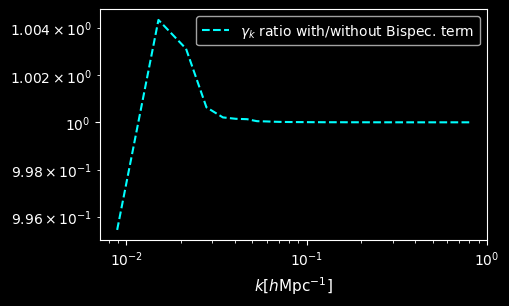

In [44]:
fig = plt.figure(figsize = (5,3))
#plt.plot(k, roots_nb[:,1].real/k**2, label = "Without Bk Term", ls = "--", zorder =3, color = "red")
plt.plot(k, solution["x"]/roots_nb[:,1].real, label = r"$\gamma_k$" + " ratio with/without Bispec. term", ls = "--", zorder =3, color = "cyan")
plt.legend(fontsize = 12)
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
#plt.ylabel(r"$\gamma_k/k^2$", fontsize = 11)
plt.loglog()
plt.legend()

In [45]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)
MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

weights1D = solution["x"]#roots[:,1].real/(k**2)
# Put gamma_k weights in 3D
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_sol = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_sol = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_sol = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

0.0 1.3929979117318794
True


In [46]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected_sol= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected_alt, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_sol, a_x_sol.astype("float32"), a_y_sol.astype("float32"), a_z_sol.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

delta_corrected_sol=get_delta(pos=pos_corrected_sol, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected_sol, Pk_disp_sol, _, _ = compute_Pk(delta_corrected_sol, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256

Using CIC mass assignment scheme
Time taken = 1.811 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds


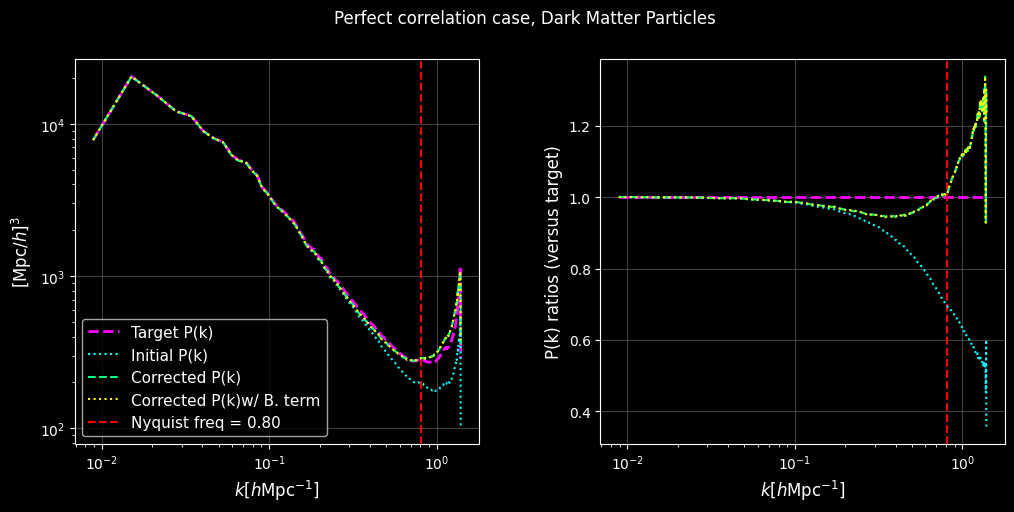

In [49]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

# temporary fix
kplot = k_corrected_alt.copy()

ax1.plot(kplot, Pk_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(kplot, Pk_pm, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(kplot, Pk_disp_alt, color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax1.plot(kplot, Pk_disp_sol, color = "yellow", lw = 1.5, label = "Corrected P(k)w/ B. term", ls = "dotted", zorder = 5)
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kN)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(kplot, Pk_target/Pk_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(kplot, Pk_pm/Pk_target, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(kplot, Pk_disp_alt/Pk_target, color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax2.plot(kplot, Pk_disp_sol/Pk_target, color = "yellow", lw = 1.5, label = "Corrected P(k) w/ B. term", ls = "dotted", zorder = 5)
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
#ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("linear")
ax2.grid(color = "grey", alpha = 0.5)
plt.subplots_adjust(wspace = 0.3)
plt.suptitle("Perfect correlation case, Dark Matter Particles")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kN)

# 3) Dark Matter Particles - uncorrelated case

We assume a perturbation field so that
The correlation function of the perturbation field is such that
\begin{align}
\langle \phi_{\mathbf{q}} \phi_{\mathbf{q}'}^* \rangle &= (2\pi)^3 \delta(\mathbf{q} - \mathbf{q}') Q(q) \text{ (continuous case)} \\
\langle \phi_{\mathbf{q}} \phi_{\mathbf{q}'}^* \rangle &=\delta_D(\mathbf{q},\mathbf{q'}) \frac{Q(q)}{V}  \text{ (continuous, periodic case)}
\end{align}


\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\phi} &\approx |\Delta_{\mathbf{k}}^2| + k^4  \frac{Q(k)}{V} +\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q)|\Delta_{\mathbf{k-q}}|^2 \\
&+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\mathbb{E}_{\phi}[\phi_{\mathbf{k}}^{\ast}] +\frac{k^4}{V} Q(k)\Delta_{\mathbf{0}}^{\ast} \right. \nonumber \\
 &+\left. \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) 
\mathbb{E}_{\phi}[\phi_{\mathbf{q}}^{\ast}]\Delta_{\mathbf{k}}\Delta_{\mathbf{k-q}}^{\ast}
 \right. \nonumber \\
 &- \left. \frac{1}{2V} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q) \Delta_{\mathbf{k}}\Delta^{\ast}_{\mathbf{k}}\right]\,.
\end{align}
In the last term, we used $\Phi_{\mathbf{q}}^{\ast} = \Phi_{\mathbf{-q}}$, and then, for the expectation, $-\mathbf{q} = \mathbf{q}^{'}$ so that for the modulus $q$ appears and only $\mathbf{k}$ remains in the $\Delta$ term. Note that this introduces also a minus sign in front of the last term.

Finally, let's take the expectation over particle configurations $\Delta$

\begin{align}
    V \langle \langle |\Delta'_{\mathbf{k}}|^2\rangle_{\phi} \rangle_{\Delta}&\approx P(k) + k^4 Q(k)
    +\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q)P(|\mathbf{k}-\mathbf{q}|) \nonumber \\
    &- \frac{1}{V} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q) P(k)
\end{align}


periodic box of side $L$, allowed modes are
spaced by $\Delta k = 2\pi/L$ per axis, so each occupies a $k$-space volume $(2\pi)^3/V$. This gives,
independent of any choice of forward/inverse $1/V$ placement in the $\Delta_\mathbf{k}$ transform pair,
\begin{equation}
\sum_{\mathbf{q}} F(\mathbf{q}) \;\longrightarrow\; \frac{V}{(2\pi)^3}\int F(\mathbf{q})\, d^3q .
\end{equation}


To compute the angular integral of $(\mathbf{k} \cdot \mathbf{q})^2 Q(q) P(|\mathbf{k}-\mathbf{q}|)$ we'll keep $|\mathbf{k}| = k$ fixed, while the modulus $q$ can vary.
 There is only one angular integral over $\Omega_\mathbf{q}$, since the sum is over $\mathbf{q}$, and not over $\Omega_\mathbf{k}$.
 
Rewrite the dot product $(\mathbf{k} \cdot \mathbf{q})^2$ in terms of the cosine of the angle between $\mathbf{k}$ and $\mathbf{q}$:

   $$(\mathbf{k} \cdot \mathbf{q})^2 = k^2 q^2 \cos^2 \theta,$$
where $\theta$ is the angle between $\mathbf{k}$ and $\mathbf{q}$.

Express the integral in spherical coordinates
$$I(k, q) = \int d\Omega_\mathbf{q} \, k^2 q^2 \cos^2 \theta \, Q(q) P(|\mathbf{k}-\mathbf{q}|).$$

The magnitude of the difference vector $|\mathbf{k}-\mathbf{q}|$ can be expressed in terms of $k$, $q$, and $\theta$ using the cosine law
$$|\mathbf{k}-\mathbf{q}|^2 = k^2 + q^2 - 2kq \cos \theta.$$

Expand the integral in spherical coordinates

$$I(k, q) = \int_0^{2\pi} d\phi_q \int_0^{\pi} d\theta_q \sin \theta_q \, k^2 q^2 \cos^2 \theta \, Q(q) P(\sqrt{k^2 + q^2 - 2kq \cos \theta}).$$

The integral $\phi_q$  gives a factor of $2\pi$.  The integrand only depends on the angle between $\mathbf{k}$ and $\mathbf{q}$. Therefore, the integration over $\hat{\mathbf{q}}$ will give the same result for any fixed $\hat{\mathbf{k}}$. To evaluate the integration over $\hat{\mathbf{q}}$ we can choose $\hat{\mathbf{k}}$ along  
$\hat{\mathbf{z}}$, since the value of the integral does not depend on that choice. Then the integral over $\theta_q$ can be performed using the substitution $\cos \theta = \hat{\mathbf{k}} \cdot \hat{\mathbf{q}}$
$$I(k, q) = k^2 q^2 Q(q) \int_0^{2\pi} d\phi_k \int_{-1}^{1} d(\cos \theta) \cos^2 \theta \, P(\sqrt{k^2 + q^2 - 2kq \cos \theta}).$$

$$I(k, q) = 2\pi k^2 q^2 Q(q) \int_{-1}^{1} d(\cos \theta) \cos^2 \theta \, P(\sqrt{k^2 + q^2 - 2kq \cos \theta}).$$

The angular part is then
$$I(k, q) = 2\pi k^2 q^2 Q(q) \int_{-1}^{1}\, P(\sqrt{k^2 + q^2 - 2kq z}) z^2 dz $$

This expression can be evaluated numerically for given power spectra $Q(q)$ and $P(k)$. 

\begin{align}
J_1(k) &= \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k}\cdot\mathbf{q})^2 Q(q) P(|\mathbf{k}-\mathbf{q}|)
\;\longrightarrow\; \frac{1}{(2\pi)^3}\int_0^{q_{\mathrm{max}}} q'^2 I(k,q')\, dq' \\
&= \frac{k^2}{(2\pi)^2} \int_0^{q_{\mathrm{max}}} q'^4 Q(q') \left[\int_{-1}^1 P(\sqrt{k^2+q'^2-2kq'z})\, z^2\, dz\right] dq'
\end{align}

The additional term, when using $\Phi$ up to second order in the perturbed field density
contrast, can be computed similarly with $P(|\mathbf{k}-\mathbf{q}|)$ replaced by $P(k)$ in the previous
equations, which can be put out of the integral that simply becomes $\int_{-1}^1 z^2 dz = \frac{2}{3}$.

\begin{equation}
J_2(k) = \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k}\cdot\mathbf{q})^2 Q(q) P(k)
\;\longrightarrow\; \frac{2k^2 P(k)}{3(2\pi)^2} \int_0^{q_{\mathrm{max}}} q'^4 Q(q')\, dq'
\end{equation}

## 3-1) Q computations
We look at both first and second order systems (in $\Phi$)

In [64]:
def build_Q_matrix(k, Pk, n_y=201):
    """
    Build N such that P_target - P = N @ Q  (uncorrelated-perturbation system),
    and N1, N2 such that:
        J1(k) = N1 @ Q   (cross term,  ~ P(|k-q|))
        J2(k) = N2 @ Q   (self term,   ~ P(k))
        N = diag(k**4) + N1 - N2

    I(k,q) = integral_{-1}^{1} y^2 * P(sqrt(k^2+q^2-2kqy)) dy

    Parameters
    ----------
    k    : (n_k,) array - k-bin centers [h/Mpc], used both as target k and as q
    Pk   : (n_k,) array - P(k) at those bins
    n_y  : int          - number of y=cos(theta) samples for the inner integral

    Returns
    -------
    N, N1, N2 : (n_k, n_k) arrays
    """
    n_k = len(k)
    P_interp = interp1d(k, Pk, kind="linear", bounds_error=False,
                         fill_value=(Pk[0], Pk[-1]))

    y = np.linspace(-1, 1, n_y)

    # I[i,j] = integral_y y^2 * P(sqrt(k_i^2 + q_j^2 - 2 k_i q_j y)) dy
    I_mat = np.zeros((n_k, n_k))
    for i, ki in enumerate(k):
        for j, qj in enumerate(k):
            kq = np.sqrt(np.clip(ki**2 + qj**2 - 2*ki*qj*y, 0, None))
            I_mat[i, j] = np.trapz(y**2 * P_interp(kq), y)

    # trapz weights for the outer integral over q_j
    dk        = np.empty(n_k)
    dk[1:-1]  = (k[2:] - k[:-2]) / 2
    dk[0]     = (k[1]  - k[0])   / 2
    dk[-1]    = (k[-1] - k[-2])  / 2

    prefac = (k[:, None]**2 / (2*np.pi)**2) * (k[None, :]**4) * dk[None, :]

    N1 = prefac * I_mat                  # J1(k) = N1 @ Q
    N2 = prefac * (Pk[:, None]*2/ 3.)     # J2(k) = N2 @ Q

    N = np.diag(k**4) + N1 - N2

    return N, N1, N2


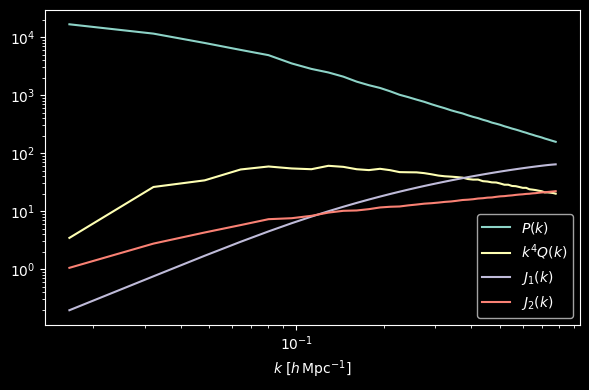

In [65]:
N, N1, N2 = build_Q_matrix(k, Pk_pm)
dP        = Pk_target - Pk_pm
Q_sol     = np.linalg.solve(N, dP)

J1 = N1 @ Q_sol
J2 = N2 @ Q_sol

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k, Pk_pm,        label=r"$P(k)$")
ax.plot(k, k**4 * Q_sol, label=r"$k^4 Q(k)$")
ax.plot(k, J1,           label=r"$J_1(k)$")
ax.plot(k, J2,           label=r"$J_2(k)$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
ax.legend()
plt.tight_layout()


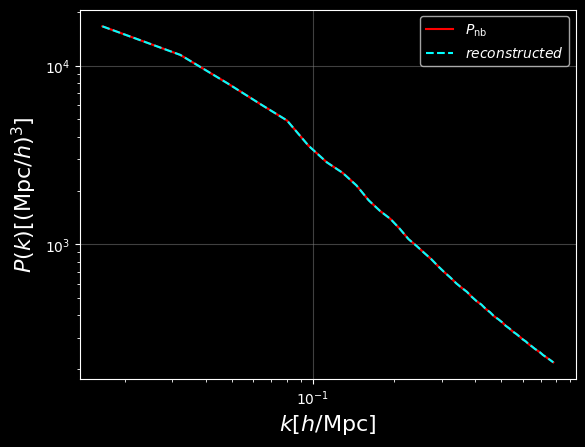

In [68]:
A = plt.figure()
plt.loglog(k_nb, Pk_nb, color = "red", label = r"$P_{\mathrm{nb}}$")
plt.loglog(k_pm, Pk_pm +k_pm**4 * Q_sol + J1 - J2, color = "cyan", ls = "--", label = r"$reconstructed$")
plt.legend()
plt.xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
plt.ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
plt.grid(color = "grey", alpha = 0.5)

## 3-2) Move particles with Q

In [69]:
# ------------------------------------------------------------------
# Uncorrelated case: generate phi_k from white noise with P(k)=Q(k),
# same structure as the correlated (gamma) case above.
# ------------------------------------------------------------------

scale = 2*np.pi*grid/BoxSize  # k sampling rate

kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift=True)

# Precision setup, matching the correlated-case cell
prec_dict = {"float32": "complex64", "float64": "complex128", "complex64": "complex64"}
prec_in = "complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

# --- Forward FFT of white noise (replaces FFT of delta_pm in the correlated case) ---
rng = np.random.default_rng(seed)
white_noise = rng.normal(0., 1., size=(grid, grid, grid)).astype(prec_in)

a_in  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
a_out = pyfftw.empty_aligned((grid, grid, grid), dtype='complex64')
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0, 1, 2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)

a_in[:] = white_noise
white_noise_fourier = fftw_plan(a_in, a_out)
white_noise_fourier_shift = np.fft.fftshift(white_noise_fourier, axes=(0, 1, 2))

# --- Build the 3D sqrt(Q(k)/cell_volume) weight grid 
cell_volume = (BoxSize/grid)**3
Q_safe = np.clip(Q_sol, 0., None)               # guard against negative Q(k)

# ΔV = V/N is exactly the cell volume — it's the conversion factor between "variance per discrete grid cell" 
#(what white noise naturally gives) and "power per unit physical volume" (what Q(k) is defined as).
weights1D = np.sqrt(Q_safe / cell_volume)

weights_grid = np.empty(white_noise_fourier_shift.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius, k, weights1D, extra_right=0.)

# --- phi_k for the uncorrelated case ---
phi_k_Q = weights_grid * white_noise_fourier_shift

# --- Gradient (acceleration) in Fourier space, same recipe as the correlated case ---
grad_x_fourier_Q = 1.0j * kx_v[:, np.newaxis, np.newaxis] * phi_k_Q
grad_y_fourier_Q = 1.0j * ky_v[np.newaxis, :, np.newaxis] * phi_k_Q
grad_z_fourier_Q = 1.0j * kz_v[np.newaxis, np.newaxis, :] * phi_k_Q

arr_inx  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz = pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0, 1, 2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0, 1, 2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0, 1, 2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

arr_inx[:] = grad_x_fourier_Q.astype(prec_out)
arr_iny[:] = grad_y_fourier_Q.astype(prec_out)
arr_inz[:] = grad_z_fourier_Q.astype(prec_out)

a_x_Q = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_Q = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_Q = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid
length_grid = np.arange(start=0., stop=BoxSize, step=cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid


1.382115115546474
(221,)
(256,)


[None, None]

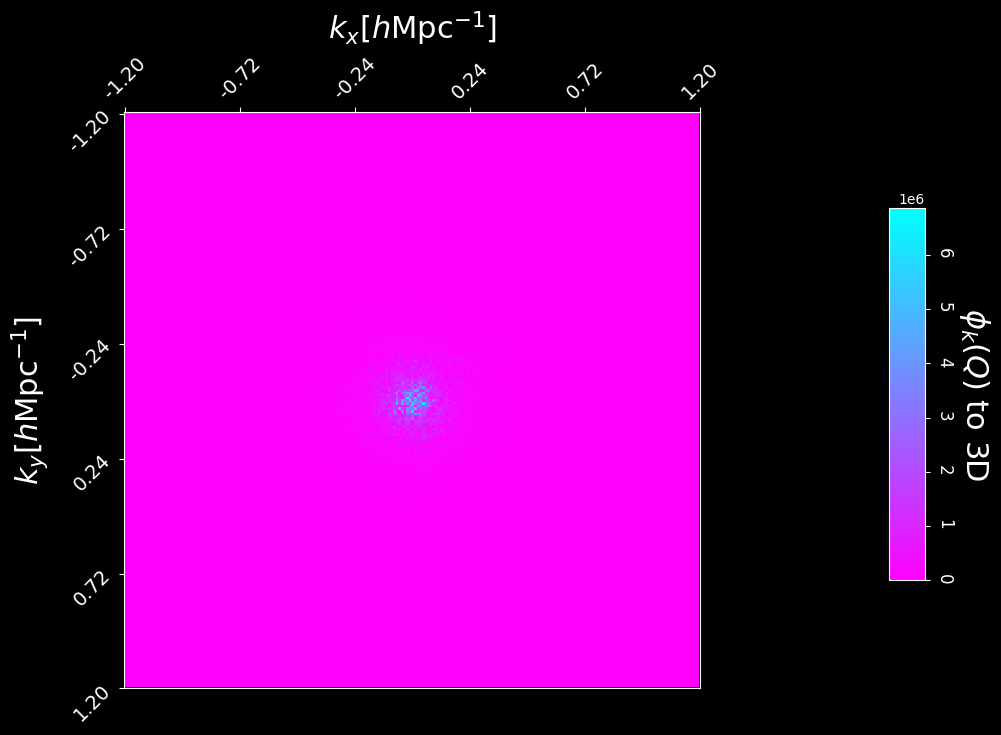

In [71]:
fig, ax1 = plt.subplots(figsize = (12, 6), nrows = 1, ncols = 1, 
                         sharex = False, sharey = False)

div_cmap = cm.cool_r
div_cmap.set_bad('black',1.)
origin = "upper"

#kpl = kx_v*np.sqrt(3)
freq = np.fft.fftshift(np.fft.fftfreq(grid))
kpl = scale * freq * np.sqrt(3)
print(kpl.max())
kmip = -1.2
kmap = -kmip

fshift = True
indp = np.where((kpl>=kmip)&(kpl<=kmap))[0]
print(indp.shape)
print(kpl.shape)
logscale = False
fact = 1.
#fact = np.sqrt(2)
indcut = 0 if not fshift else len(freq)//2 + 1
if logscale:
    im1 = ax1.matshow(abs(phi_k_Q[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      norm=colors.LogNorm(vmin=1e-2, vmax=abs(phi_k_Q[:,:,indcut]).max()))

else:
    im1 = ax1.matshow(abs(phi_k_Q[indp.min():indp.max(),indp.min():indp.max(),indcut]),cmap = div_cmap, origin = origin, 
                      vmin = abs(phi_k_Q[:,:,indcut]).min(), vmax = abs(phi_k_Q[:,:,indcut]).max())

# Colorbar setting
# can also use cbar = plt.colorbar(im1), and myCbar = cbar.ax
plt.subplots_adjust(bottom = 0.02, top = 0.98, right = 0.90, wspace = 0.45, hspace = 0.15)
myCbar = fig.add_axes(rect = [0.91, 0.2, 0.03, 0.62]) # left, bottom, width, height

cb = fig.colorbar(im1, cax=myCbar)
#cb.ax.minortickskN_off()
myCbar.tick_params(labelsize = 12, rotation = 270)
myCbar.set_ylabel(r"$\phi_k(Q)$" + " to 3D", fontsize = 22, rotation = 270)
myCbar.get_yaxis().labelpad = 28

fmtM = lambda x:"{:1.2f}".format(x)
labelM = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)
labelH = np.linspace(0, kpl[indp].shape[0] - 1, 6, dtype = int)

ax1.set_xlabel(r"$k_x [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_ylabel(r"$k_y [h\mathrm{Mpc}^{-1}]$", fontsize = 22, labelpad = 10)
ax1.set_xticks(labelM)
ax1.set_yticks(labelM)
ax1.set_xticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_ticks_position('top')
ax1.set_yticklabels([fmtM(j) for j in kpl[indp][labelM]], rotation = 45, fontsize = 14)
ax1.xaxis.set_label_position('top')
ax1.yaxis.set_label_position('left')
ax1.set(adjustable='box', aspect='equal')
#ax1.set_title("With Halo code (np.digitize)", fontsize = 20)


1.090113
3.9714463
float32


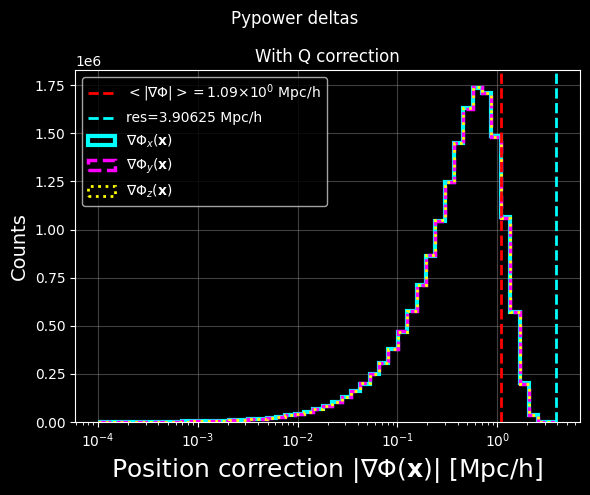

In [75]:
mean_dispQ = np.mean(np.sqrt(a_x_Q**2 + a_y_Q**2+a_z_Q**2 ))
max_disp = np.sqrt(a_x_Q**2 + a_y_Q**2+a_z_Q**2 ).max()
print(mean_dispQ)
print(max_disp)
print(a_x_Q.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, ax1 = plt.subplots(1,1, figsize = (6,5), sharey = True)
ax1.axvline(x = mean_dispQ,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_dispQ))
ax1.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax1.hist(np.abs(a_x_Q.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax1.hist(np.abs(a_y_Q.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax1.hist(np.abs(a_z_Q.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax1.set_xscale("log")
ax1.legend(fontsize = 10)
ax1.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax1.set_ylabel("density", fontsize = 14)
else:
    ax1.set_ylabel("Counts", fontsize = 14)
ax1.grid(color = "gray", alpha = 0.5)

plt.suptitle("Pypower deltas")
ax1.set_title("With Q correction")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gradient_modulus_ditribution.pdf"), bbox_inches = "tight")
#ax.set_xlim(left = 0, right = 60.)

In [72]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected_Q= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected_Q, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_Q, a_x_Q.astype("float32"), a_y_Q.astype("float32"), a_z_Q.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256


In [77]:
recompbool = False
suffstr = ""
if os.path.exists(os.path.join('precomps', "pypower_dispQ_%i_bins%s.npy"%(num_bins, suffstr))) and not recompbool:
    print("LOADING PYPOWER COMPUTATIONS")
    k_disp_Q = np.load(os.path.join('precomps', 'kdispQ_%i_bins%s.npy'%(num_bins, suffstr)))
    Pk_disp_Q = np.load(os.path.join('precomps', "pypower_dispQ_%i_bins%s.npy"%(num_bins, suffstr)))

    k_disp_Qr = np.load(os.path.join('precomps', 'kdispQr_%i_bins%s.npy'%(num_bins, suffstr)))
    Pk_disp_Qr = np.load(os.path.join('precomps', "pypower_dispQr_%i_bins%s.npy"%(num_bins, suffstr)))
    k_Xdisp = np.load(os.path.join('precomps', 'kXdispQ_%i_bins%s.npy'%(num_bins, suffstr)))
    Pk_Xdisp = np.load(os.path.join('precomps', "pypower_XdispQ_%i_bins%s.npy"%(num_bins, suffstr)))
else:
    print("RUNNING PYPOWER COMPUTATIONS")
    start = time.time()
    result_Q = CatalogFFTPower(data_positions1=pos_corrected_Q, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')

    result_Xdisp = CatalogFFTPower(data_positions1=pos_nb, data_positions2 = pos_corrected_Q, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    #result_pm.poles(remove_shotnoise=False)
    poles_Q = result_Q.poles
    k_disp_Q, Pk_disp_Q = poles_Q(ell=ells, return_k=True, complex=False)

    # For cross coeffs
    k_disp_Qr, Pk_disp_Qr = poles_Q(ell=ells, return_k=True, complex=False, remove_shotnoise=False)

    np.save(os.path.join('precomps', 'kdispQ_%i_bins%s.npy'%(num_bins, suffstr)),k_disp_Q)
    np.save(os.path.join('precomps', "pypower_dispQ_%i_bins%s.npy"%(num_bins, suffstr)), Pk_disp_Q)
    np.save(os.path.join('precomps', 'kdispQr_%i_bins%s.npy'%(num_bins, suffstr)),k_disp_Qr)
    np.save(os.path.join('precomps', "pypower_dispQr_%i_bins%s.npy"%(num_bins, suffstr)), Pk_disp_Qr)

    poles_Xdisp = result_Xdisp.poles
    k_Xdisp, Pk_Xdisp = poles_Xdisp(ell=ells, return_k=True, complex=False)
    np.save(os.path.join('precomps', 'kXdispQ_%i_bins%s.npy'%(num_bins, suffstr)),k_Xdisp)
    np.save(os.path.join('precomps', "pypower_XdispQ_%i_bins%s.npy"%(num_bins, suffstr)), Pk_Xdisp)

    end = time.time()
    print("%.2f seconds of computation for both pypower calculations"%(end-start))

RUNNING PYPOWER COMPUTATIONS
278.39 seconds of computation for both pypower calculations


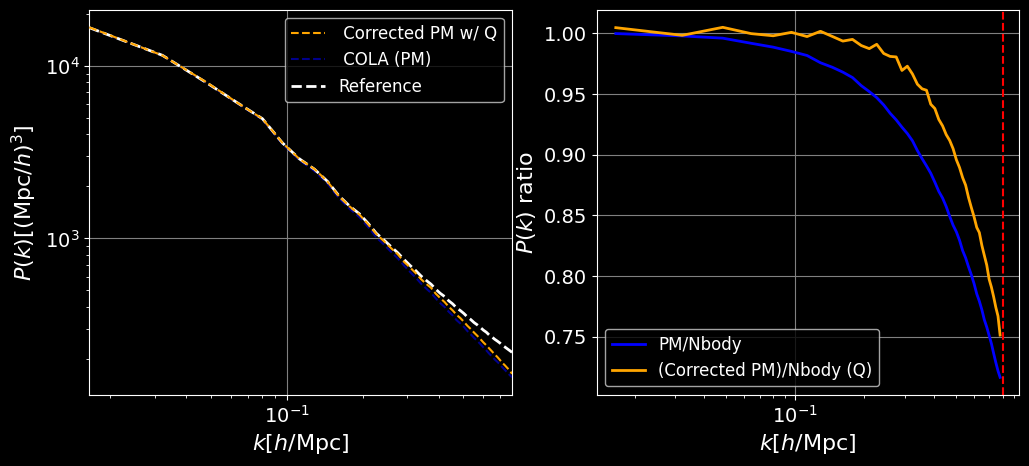

In [79]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
#ax1.plot(k_pm, Pk_pm, label=" COLA Pylians", zorder = 3, color = "cyan")
#ax1.plot(k_nb, Pk_nb, label='Quijote Pylians', lw = 2, color = "white", zorder = 4)
ax1.plot(k_disp_Q, Pk_disp_Q, label=" Corrected PM w/ Q", zorder = 5, color = "orange", ls = "--")
ax1.plot(k_pm, Pk_pm, label=" COLA (PM)", zorder = 3, color = "darkblue", ls = "--")
ax1.plot(k_nb, Pk_nb, label='Reference', lw = 2, color = "white", zorder = 4, ls = "--")
#ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "dotted", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
#ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax1.tick_params(labelsize = 14)

#ko, Po = poles_pm(return_k=True, complex=False)
#kk, Pkk = poles_nb(complex = False, return_k = True)
#kcc, Pcc = poles_corr(complex = False, return_k = True)
#ax2.plot(k_pm, Pk_pm/poles_pm(k=k_pm, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 4, color = "crimson", ls = "--")
#ax2.plot(ko, Po[0,:]/Pk_nb, label='Corrected/Nbody', zorder = 3, color = "springgreen")
ax2.plot(k_nb, Pk_pm/Pk_nb, label='PM/Nbody', zorder = 3, color = "blue", lw=2)
ax2.plot(k_disp_Q, Pk_disp_Q/Pk_nb, label='(Corrected PM)/Nbody (Q)', zorder = 3, color = "orange", lw = 2)

ax2.legend(fontsize = 12)

ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax2.tick_params(labelsize = 14)
#x2.set_ylim(top = 1.05, bottom = 0.9)
ax1.set_xlim(left = k_disp_Q.min(), right =  k_disp_Q.max())
plt.savefig(os.path.join(figroot, "Pk_results_uncorrelated.pdf"), bbox_inches = "tight")

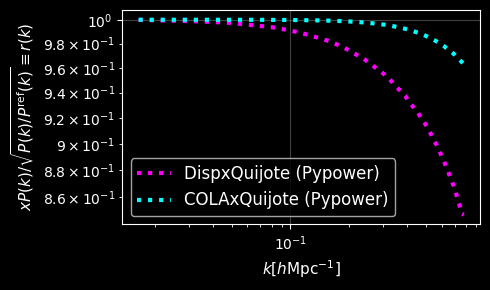

In [80]:
dispint = np.interp(k_Xdisp, k_disp_Qr, Pk_disp_Qr)

fig, axes = plt.subplots(1,1, figsize = (5,3))
axes.plot(k_Xdisp, Pk_Xdisp/np.sqrt(dispint*nbint), ':', label='DispxQuijote (Pypower)', zorder= 10, lw = 3, color = "magenta")
axes.plot(k_X, Pk_X/np.sqrt(nbint*pmint), ':', label='COLAxQuijote (Pypower)', zorder= 10, lw = 3, color = "cyan")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)/P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()
plt.savefig(os.path.join(figroot, "crosscorr_disp_nbody.pdf"), bbox_inches = "tight")

## 3-3) Old Mess

In [38]:
def calculate_J_terms(k, Pk0, BoxSize, dz = 1e-3):
    
    J1=np.zeros([len(k), len(k)])
    J2=np.zeros([len(k), len(k)])
    z=np.arange(-1,1-dz,dz)

    diff_k = np.mean(np.diff(k))
    
    for i,ki in enumerate(k):
        for j,qj in enumerate(k):
            k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)
            Pk_nl=np.interp(k_in, k, Pk0)
            if ki==qj:
                Pk_nl[-1]=0

            # J as matrices are here the I terms including the integral/sum over the radial part
            J1[i,j]=2*np.pi*ki**2*qj**2*np.trapz(Pk_nl*z**2,z) * qj**2 * diff_k
            J2[i,j]=2*np.pi*ki**2*qj**2*(2./3.)*Pk0[i] * qj**2 * diff_k

    # Is the 1/V**2 factor correct ? 09/04/2026 : changing to 1/V
    J1*= np.power(2*np.pi/BoxSize,3) 
    J2*= 0.5*np.power(2*np.pi/BoxSize,3)

    return J1, J2

def Q_solver(Qk, k, Pk0, Pk0_target, BoxSize, dz = 1e-3):

    J1, J2 = calculate_J_terms(k, Pk0, BoxSize, dz = 1e-3)
    system = Pk0 - Pk0_target + k**4 * Qk
    system += np.trapz(k**2*Qk*I1,k) + np.trapz(k**2*Qk*I2) # += J1 + J2

    return system

# def Q_solver(k, Pk0, Pk0_target, BoxSize, dz = 1e-3):

#     I1, I2 = calculate_J_terms(k, Pk0, BoxSize, dz = 1e-3)

#     J3=np.identity(len(k))
#     for i, ki in enumerate(k):
#         J3[i,i]*=ki**4

#     system1 =  J1
#     system2 =  J1 - J2

#     B = -1.* (Pk0_target-Pk0) # putting on left side of equationPk0 - Pk0_target

#     Qk1=np.matmul(np.linalg.inv(system1),B)
#     Qk2=np.matmul(np.linalg.inv(system2),B)

#     return Qk1,Qk2, J1, J2

def Q_linear_solver(k, Pk0, Pk0_target, BoxSize, dz = 1e-3):

    J1, J2 = calculate_J_terms(k, Pk0, BoxSize, dz = 1e-3)
    
    J3=np.identity(len(k))
    for i, ki in enumerate(k):
        J3[i,i] *= ki**4
    
    system1 =  J1 + J3
    system2 =  J1 - J2 + J3
    
    B = Pk0_target-Pk0 # putting on left side of equationPk0 - Pk0_target
    
    Qk1=np.matmul(np.linalg.inv(system1),B)
    Qk2=np.matmul(np.linalg.inv(system2),B)
    
    return Qk1, Qk2, J1, J2

In [39]:
inds = np.where(k_nb <= kN)
k = k_nb[inds]
Q_first, Q_second, J1, J2 = Q_linear_solver(k, Pk_pm[inds], Pk_nb[inds], BoxSize, dz = 1e-3)

/tmp/ipykernel_2929551/1188581951.py:11: RuntimeWarning: invalid value encountered in sqrt
  k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)


LinAlgError: 1-dimensional array given. Array must be at least two-dimensional

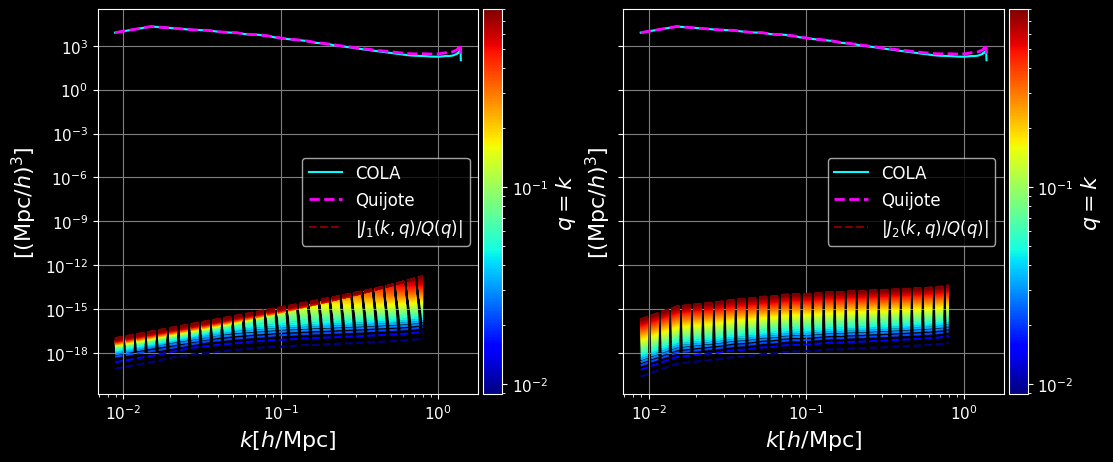

In [99]:
#colorsc = plt.cm.jet(np.linspace(0,1,(len(k))))
from matplotlib import colors, cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

cmap1 = cm.jet
norm1 = colors.LogNorm(vmin=k.min(), vmax=k.max())
print(norm)
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False, sharey = True)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "magenta", zorder = 4)
ax2.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax2.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "magenta", zorder = 4)
for n in range(len(k)):
    l1 = r"$|J_1(k,q)/Q(q)|$" if n==len(k)-1 else None
    l2 = r"$|J_2(k,q)/Q(q)|$" if n==len(k)-1 else None
    ax1.plot(k, abs(J1[:,n]), color = cmap1(norm1(k[n])), ls = "--", zorder = 5, label = l1)
    ax2.plot(k, abs(J2)[:,n], color = cmap1(norm1(k[n])), ls = "--", zorder = 5, label = l2)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)
#fig.colorbar(colors ,ax=ax1, label="dy/dx")

ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_ylabel(r"$[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax2.grid(color = "grey")
ax2.tick_params(labelsize = 11)

divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
sm = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)

cbar = fig.colorbar(sm,cax =cax)
cbar.set_label(r"$q=k$", fontsize = 16)
cbar.ax.tick_params(labelsize=11)

divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='5%', pad=0.05)
sm = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)

cbar = fig.colorbar(sm,cax =cax)
cbar.set_label(r"$q=k$", fontsize = 16)
cbar.ax.tick_params(labelsize=11)
plt.subplots_adjust(wspace = 0.3)

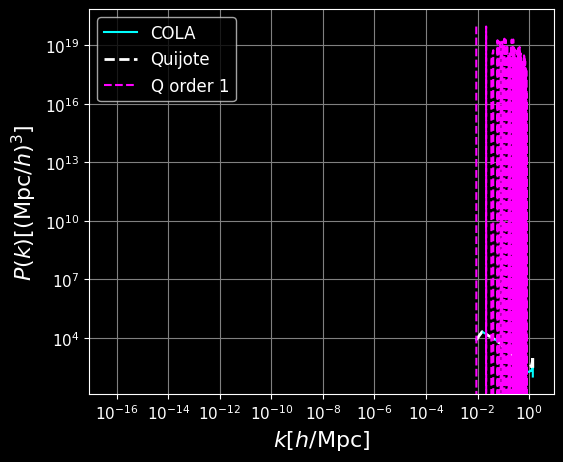

In [56]:
fig, ax1 = plt.subplots(figsize = (6,5), ncols = 1, nrows = 1, sharex = False)
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "white", zorder = 4)
ax1.plot(k, Q_first, label='Q order 1', color = "magenta", ls = "--", zorder = 5)
ax1.plot(k, Q_second, label='Q order 2', color = "springgreen", ls = "dotted", zorder = 6)
#ax1.plot(k, Q_second, label='Q order 2', color = "yellow", ls = "--", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)

In [48]:

def get_phi(k, Qk, grid=128, BoxSize=1000.0, Rayleigh_sampling=1, seed=1, threads=1, verbose=True):
    
    # seed              = 1      #value of the initial random seed
    # Rayleigh_sampling = 1      #whether sampling the Rayleigh distribution for modes amplitudes
    # threads           = 1      #number of openmp threads
    # verbose           = True   #whether to print some information

    k, Qk = k.astype(np.float32), Qk.astype(np.float32)

    # generate a 3D Gaussian density field
    phi = DFL.gaussian_field_3D(grid, k, Qk, Rayleigh_sampling, seed,
                                  BoxSize, threads, verbose)

    return phi

In [ ]:
phi_1 = get_phi(k, Q_first, grid=grid, BoxSize=BoxSize, Rayleigh_sampling=0)
phi_2 = get_phi(k, Q_second, grid=grid, BoxSize=BoxSize, Rayleigh_sampling=0)
print(phi_1.dtype)

In [ ]:
# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = phi_1.astype(prec_in)
phi_1_fourier = fftw_plan(a_in,a_out)

phi_1_fourier_shift = np.fft.fftshift(phi_1_fourier, axes=(0,1,2))

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = phi_2.astype(prec_in)
phi_2_fourier = fftw_plan(a_in,a_out)

phi_2_fourier_shift = np.fft.fftshift(phi_2_fourier, axes=(0,1,2))

In [ ]:
# MY RECIPE (phi1)
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]

freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_1_fourier_shift
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_1_fourier_shift
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_1_fourier_shift

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_1 = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_1 = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_1 = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

In [ ]:
# MY RECIPE (phi2)
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]

freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_2_fourier_shift
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_2_fourier_shift
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_2_fourier_shift

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_2 = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_2 = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_2 = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

In [ ]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected_1= np.empty(pos_pm.shape).astype(prec_in)
pos_corrected_2= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected_1, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_1, 
                                            a_x_1.astype("float32"), a_y_1.astype("float32"), a_z_1.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

pos_corrected_2, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_2, 
                                            a_x_2.astype("float32"), a_y_2.astype("float32"), a_z_2.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

In [ ]:
mean_disp = np.mean(np.sqrt(a_x_1**2 + a_y_1**2+a_z_1**2 ))
max_disp = np.sqrt(a_x_1**2 + a_y_1**2+a_z_1**2 ).max()
print(mean_disp)
print(max_disp)
print(a_x_1.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.abs(a_x_1.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax.hist(np.abs(a_y_1.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax.hist(np.abs(a_z_1.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.suptitle("Pypower deltas")
plt.suptitle("With MAS correction")
plt.tight_layout()
plt.savefig(os.path.join(figroot, "gradient_modulus_ditribution.pdf"), bbox_inches = "tight")
#ax.set_xlim(left = 0, right = 60.)